# Analyse par période — sélection R² > 0.2 et n > 30 (E_i signé)

Notebook autonome : préparation (chargement, matrices A_ij, fenêtres croissantes, crise par actif), R² moyen SIS↔E_i signé par période et par matrice, sélection des périodes (n > 30 actifs et R² moyen > 0.2), puis courbes / spaghettis / scatter agrégé sur les périodes retenues.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os, time, glob, pickle, hashlib
from scipy.integrate import solve_ivp
from scipy.ndimage import uniform_filter1d
from scipy.stats import linregress
from functions import load_data, correlation

plt.rcParams['figure.dpi'] = 80

# ── Cache disque : les calculs lourds (PMFG ~44 s, VAR, fits SIS) ne sont ────
#    faits qu'une seule fois puis rechargés depuis .cache/periods_analysis/.
#    Mets FORCE_RECOMPUTE = True (ou supprime le dossier) pour tout recalculer.
CACHE_DIR = '.cache/periods_analysis'
os.makedirs(CACHE_DIR, exist_ok=True)
FORCE_RECOMPUTE = False

def _hash_update(h, obj):
    if isinstance(obj, np.ndarray):
        h.update(b'a'); h.update(np.ascontiguousarray(obj).tobytes())
        h.update(str(obj.shape).encode())
    elif isinstance(obj, pd.DataFrame):
        h.update(b'df'); h.update(np.ascontiguousarray(obj.values).tobytes())
        h.update(repr(list(obj.columns)).encode())
    elif isinstance(obj, dict):
        h.update(b'd')
        for k in sorted(obj, key=repr):
            h.update(repr(k).encode()); _hash_update(h, obj[k])
    elif isinstance(obj, (list, tuple)):
        h.update(b's')
        for x in obj:
            _hash_update(h, x)
    else:
        h.update(repr(obj).encode())

def make_sig(*parts):
    """Signature courte (md5) des entrées : invalide le cache si elles changent."""
    h = hashlib.md5()
    for p in parts:
        _hash_update(h, p)
    return h.hexdigest()[:16]

def disk_cache(name, sig, compute, force=None):
    """Charge name depuis le disque si la signature correspond, sinon (re)calcule."""
    force = FORCE_RECOMPUTE if force is None else force
    path = os.path.join(CACHE_DIR, f'{name}.{sig}.pkl')
    if not force and os.path.exists(path):
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        print(f'[cache] OK  {name}  (rechargé depuis {path})')
        return obj
    for old in glob.glob(os.path.join(CACHE_DIR, f'{name}.*.pkl')):
        os.remove(old)                      # purge des versions périmées
    print(f'[cache] ..  {name}  (calcul en cours)')
    t0 = time.time()
    obj = compute()
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'[cache] OK  {name}  (calculé en {time.time() - t0:.1f} s, sauvé -> {path})')
    return obj

# ── Chargement ────────────────────────────────────────────────────────────────
data = load_data(['stock'], log_returns=True, sort_by_sector=True)
asset_names = data.columns.tolist()
N = len(asset_names)
print(f'N = {N} stocks, T = {len(data)} obs')
print(f'Période : {data.index[0]} → {data.index[-1]}')

mask_off = ~np.eye(N, dtype=bool)

# ── Secteurs (pour repérer des patterns dans la récurrence) ─────────────────
from collections import Counter as _Counter
_cat_sec     = pd.read_excel('data/stock_category.xlsx').set_index('Stocks')['Sectors']
asset_sector = {nm: _cat_sec.get(nm, '?') for nm in asset_names}
sectors      = [asset_sector[nm] for nm in asset_names]
sector_size  = _Counter(sectors)
sector_list  = sorted(set(sectors))
_cmap_sec    = plt.get_cmap('tab20')
sector_color = {s: _cmap_sec(i % 20) for i, s in enumerate(sector_list)}
gi_sector = lambda gi: asset_sector[asset_names[gi]]
gi_color  = lambda gi: sector_color[gi_sector(gi)]
print('Secteurs :', ', '.join(f'{s}({sector_size[s]})' for s in sector_list))

def barh_by_sector(gis, values, title, xlabel):
    """Barres horizontales des actifs `gis` (triés desc) colorées par secteur."""
    gis = list(gis)
    rg = gis[::-1]
    fig, ax = plt.subplots(figsize=(10, max(3, 0.32 * len(gis))))
    ax.barh([asset_names[gi] for gi in rg], [values[gi] for gi in rg],
            color=[gi_color(gi) for gi in rg], alpha=0.9)
    for tick, gi in zip(ax.get_yticklabels(), rg):
        tick.set_color(gi_color(gi))
    seen, used = set(), []
    for gi in gis:
        s = gi_sector(gi)
        if s not in seen:
            seen.add(s); used.append(s)
    ax.legend([plt.Rectangle((0, 0), 1, 1, color=sector_color[s]) for s in used],
              used, fontsize=7, loc='lower right', title='Secteur')
    ax.set_xlabel(xlabel); ax.set_title(title); ax.grid(alpha=0.3, axis='x')
    plt.tight_layout(); plt.show()

def sector_recurrence_plot(cnt, nP, title):
    """Récurrence agrégée par secteur : barre = somme des récurrences des
    actifs du secteur, annotée '<actifs distincts>/<taille du secteur>'."""
    agg, ndist = _Counter(), _Counter()
    for gi, c in cnt.items():
        s = gi_sector(gi); agg[s] += c; ndist[s] += 1
    secs = sorted(agg, key=lambda s: -agg[s])
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.45 * len(secs))))
    ax.barh(secs[::-1], [agg[s] for s in secs][::-1],
            color=[sector_color[s] for s in secs][::-1], alpha=0.9)
    for k, s in enumerate(secs[::-1]):
        ax.text(agg[s], k, f'  {ndist[s]}/{sector_size[s]} actifs', va='center', fontsize=8)
    ax.set_xlabel(f'récurrence cumulée (Σ périodes ; max {nP} par actif)')
    ax.set_title(title); ax.grid(alpha=0.3, axis='x')
    plt.tight_layout(); plt.show()
    return agg, ndist

# ── Outils PMFG / VAR ─────────────────────────────────────────────────────────
def build_pmfg(C_abs):
    n = C_abs.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    edges = sorted([(a, b, C_abs[a, b]) for a in range(n) for b in range(a+1, n)],
                   key=lambda e: -e[2])
    A = np.zeros((n, n))
    added = 0
    for a, b, w in edges:
        if added >= 3 * (n - 2):
            break
        G.add_edge(a, b)
        if nx.check_planarity(G)[0]:
            A[a, b] = A[b, a] = w
            added += 1
        else:
            G.remove_edge(a, b)
    return A

def fit_var(arr, lag):
    X = np.column_stack([np.ones(len(arr) - lag), arr[:-lag]])
    Y = arr[lag:]
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    return B[1:]

def prepare_for_sis(A_in):
    A = np.abs(A_in.T)
    np.fill_diagonal(A, 0)
    return A

# ── Calculs lourds (corr mensuelles + journalières, PMFG, VAR) → cache disque ─
def _compute_base():
    # corrélations mensuelles
    d = data.copy()
    d['year_month'] = d.index.to_period('M')
    C_by_month = {}
    for m in sorted(d['year_month'].unique()):
        chunk = d[d['year_month'] == m].drop(columns=['year_month']).values
        if len(chunk) < 10:
            continue
        Cm = np.abs(np.nan_to_num(np.corrcoef(chunk.T), nan=0.0))
        np.fill_diagonal(Cm, 0)
        C_by_month[m] = Cm
    valid_months = sorted(C_by_month.keys())

    # corrélation moyenne journalière (mc_all) + E_i journalier par actif
    da = data.copy()
    da['day'] = da.index.date
    all_days = np.array(sorted(da['day'].unique()))
    mc_all = np.full(len(all_days), np.nan)
    E_daily_all = np.full((N, len(all_days)), np.nan)
    for k, dd in enumerate(all_days):
        chunk = da[da['day'] == dd].drop(columns=['day']).values
        if len(chunk) < 3:
            continue
        C = np.abs(np.nan_to_num(np.corrcoef(chunk.T), nan=0.0))
        np.fill_diagonal(C, 0)
        mc_all[k] = C[mask_off].mean()
        E_daily_all[:, k] = C.sum(axis=1) / (N - 1)

    # corrélation pleine période + réseaux
    R_arr = data.values
    C_full = np.abs(np.nan_to_num(np.corrcoef(R_arr.T), nan=0.0))
    np.fill_diagonal(C_full, 0)
    A_pmfg = build_pmfg(C_full.copy())
    A_var1 = np.abs(fit_var(R_arr, 1).T)
    A_var13 = np.abs(fit_var(R_arr, 13).T)
    np.fill_diagonal(A_var1, 0)
    np.fill_diagonal(A_var13, 0)
    return dict(C_by_month=C_by_month, valid_months=valid_months, all_days=all_days,
                mc_all=mc_all, E_daily_all=E_daily_all, C_full=C_full,
                A_pmfg=A_pmfg, A_var1=A_var1, A_var13=A_var13)

_base = disk_cache('base', make_sig(data, N), _compute_base)
C_by_month   = _base['C_by_month']
valid_months = _base['valid_months']
all_days     = _base['all_days']
mc_all       = _base['mc_all']
E_daily_all  = _base['E_daily_all']
C_full       = _base['C_full']
A_pmfg       = _base['A_pmfg']
A_var1       = _base['A_var1']
A_var13      = _base['A_var13']
M = len(valid_months)

# ── Dérivés bon marché ────────────────────────────────────────────────────────
E_emp = np.zeros((N, M))
for t, m in enumerate(valid_months):
    E_emp[:, t] = C_by_month[m].sum(axis=1) / (N - 1)
corr_mean_by_month = np.array([C_by_month[m][mask_off].mean() for m in valid_months])
print(f'Mois exploitables : {M}')
print(f'{len(all_days)} jours, <|C_ij|> moyen = {np.nanmean(mc_all):.4f}')

# ── Dictionnaire des modèles SIS ('Corr thr' ajouté plus bas) ─────────────────
A_sis = {
    'PMFG':    A_pmfg,
    'VAR(1)':  prepare_for_sis(A_var1),
    'VAR(13)': prepare_for_sis(A_var13),
}

def ode_sis(t, x, A, B, R):
    return -B * x + R * (1.0 - x) * (A @ x)


N = 146 stocks, T = 13360 obs
Période : 2019-04-01 10:00:00 → 2023-05-03 15:30:00
Secteurs : Consumer Discretionary(16), Consumer Staples(15), Energy(11), Financials(19), Healthcare(27), Industrials(12), Information Technology(39), Materials(2), Real Estate(2), Utilities(3)
[cache] OK  base  (rechargé depuis .cache/periods_analysis/base.dcdb6398ead8c5e5.pkl)
Mois exploitables : 50
1031 jours, <|C_ij|> moyen = 0.4686


In [56]:
def increasing_intervals(y, smooth=11, min_len=10, min_gain=0.0, merge_gap=0, refine=0):
    """Detects increasing intervals in a time series after smoothing.

    Parameters
    ----------
    y : array_like
        Input time series.
    smooth : int
        Width of the moving average (noise removal).
    min_len : int
        Minimum length (in points) of a valid interval.
    min_gain : float
        Minimum smoothed gain to retain an interval.
    merge_gap : int
        Merge two increasing intervals separated by at most this many decreasing points.
    refine : int
        Shift each edge freely within ±refine to maximise raw amplitude.

    Returns
    -------
    intervals : list of (int, int)
        (start, end) inclusive pairs, sorted by decreasing smoothed gain.
    ys : numpy.ndarray
        Smoothed series.
    """
    y = np.asarray(y, float)
    ys = uniform_filter1d(y, size=smooth, mode='nearest')
    inc = np.gradient(ys) > 0

    raw, s = [], None
    for k, v in enumerate(inc):
        if v and s is None:
            s = k
        elif not v and s is not None:
            raw.append((s, k - 1))
            s = None
    if s is not None:
        raw.append((s, len(inc) - 1))

    merged = []
    for a, b in raw:
        if merged and a - merged[-1][1] - 1 <= merge_gap:
            merged[-1] = (merged[-1][0], b)
        else:
            merged.append((a, b))

    out = [(a, b) for a, b in merged
           if (b - a + 1) >= min_len and (ys[b] - ys[a]) >= min_gain]

    if refine > 0:
        n = len(y)
        adjusted = []
        for a0, b0 in out:
            best_a, best_b, best_amp = a0, b0, y[b0] - y[a0]
            for a in range(max(0, a0 - refine), min(n, a0 + refine + 1)):
                for b in range(max(0, b0 - refine), min(n, b0 + refine + 1)):
                    if (b - a + 1) < min_len:
                        continue
                    amp = y[b] - y[a]
                    if amp > best_amp:
                        best_a, best_b, best_amp = a, b, amp
            adjusted.append((best_a, best_b))
        out = adjusted

    out.sort(key=lambda ab: ys[ab[1]] - ys[ab[0]], reverse=True)
    return out, ys

In [57]:
# ── Fenêtres croissantes globales (détection + filtre de contagion) ─────────
SMOOTH        = 14
CRISIS_FACTOR = 0.7
intervals_raw, mc_smooth = increasing_intervals(
    mc_all, smooth=SMOOTH, min_len=12, merge_gap=3, refine=SMOOTH // 2)
mean_mc = np.nanmean(mc_all)
intervals = [(a, b) for a, b in intervals_raw
             if np.nanmean(mc_all[a:b + 1]) > CRISIS_FACTOR * mean_mc]
intervals_chrono = sorted(intervals, key=lambda ab: ab[0])
print(f'{len(intervals_chrono)} fenêtre(s) retenue(s) :')
for rank, (a, b) in enumerate(intervals_chrono):
    print(f'  [{rank}] {all_days[a]} → {all_days[b]}  ({b - a + 1} j)')

24 fenêtre(s) retenue(s) :
  [0] 2019-04-01 → 2019-05-13  (30 j)
  [1] 2019-07-16 → 2019-08-05  (15 j)
  [2] 2019-09-11 → 2019-10-11  (23 j)
  [3] 2019-10-30 → 2019-12-03  (24 j)
  [4] 2019-12-19 → 2020-03-09  (54 j)
  [5] 2020-05-28 → 2020-06-12  (12 j)
  [6] 2020-08-06 → 2020-09-21  (32 j)
  [7] 2020-10-13 → 2020-10-28  (12 j)
  [8] 2020-12-02 → 2020-12-21  (14 j)
  [9] 2020-12-31 → 2021-01-27  (18 j)
  [10] 2021-02-09 → 2021-03-01  (14 j)
  [11] 2021-03-23 → 2021-05-19  (41 j)
  [12] 2021-06-29 → 2021-07-19  (14 j)
  [13] 2021-08-10 → 2021-10-07  (42 j)
  [14] 2021-11-02 → 2021-12-01  (21 j)
  [15] 2021-12-28 → 2022-01-25  (20 j)
  [16] 2022-02-01 → 2022-02-28  (19 j)
  [17] 2022-04-14 → 2022-05-06  (16 j)
  [18] 2022-05-25 → 2022-06-13  (13 j)
  [19] 2022-08-03 → 2022-10-04  (44 j)
  [20] 2022-10-26 → 2022-11-10  (12 j)
  [21] 2022-12-12 → 2022-12-30  (14 j)
  [22] 2023-01-10 → 2023-02-24  (32 j)
  [23] 2023-02-28 → 2023-03-22  (17 j)


In [58]:
# ── E_i journalier par actif (depuis le cache 'base') + détection de crise ──
ASSET_FACTOR = 0.8

def _compute_crisis_map():
    cm = np.zeros((N, len(all_days)), dtype=bool)
    for i in range(N):
        y_i   = E_daily_all[i]
        thr_i = ASSET_FACTOR * np.nanmean(y_i)
        ivs, _ = increasing_intervals(y_i, smooth=SMOOTH, min_len=12,
                                      merge_gap=3, refine=SMOOTH // 2)
        for a, b in ivs:
            if np.nanmean(y_i[a:b + 1]) > thr_i:
                cm[i, a:b + 1] = True
    return cm

crisis_map = disk_cache('crisis_map',
                        make_sig(E_daily_all, ASSET_FACTOR, SMOOTH, 12, 3),
                        _compute_crisis_map)
print(f'crisis_map prêt : {crisis_map.any(axis=1).sum()} actifs avec >= 1 fenêtre.')


[cache] OK  crisis_map  (rechargé depuis .cache/periods_analysis/crisis_map.0a163d51f3c24537.pkl)
crisis_map prêt : 146 actifs avec >= 1 fenêtre.


In [59]:
# ── Hyperparamètres SIS + filtre R² ─────────────────────────────────────────
B_fit, R_fit, T_long, tol_eq = 1.0, 1.0, 50.0, 0.01
R2_MIN         = 0.2     # seuil R² par courbe (cases tracées)
CORR_THRESHOLD = 0.80    # quantile de |C| pour la matrice 'Corr thr'
SMOOTH2, MIN_LEN, MIN_GAIN = 2, 10, 0.5   # strong_rise
SIS_MODELS = ['PMFG', 'VAR(1)', 'VAR(13)', 'Corr thr']

def build_filtered_corr(q, C=C_full):
    """Corrélation filtrée prête pour le SIS : |C_ij| au-dessus du quantile q."""
    thr = np.quantile(C[mask_off], q)
    A = np.where(C >= thr, C, 0.0)
    np.fill_diagonal(A, 0)
    return prepare_for_sis(A)

A_sis['Corr thr'] = build_filtered_corr(CORR_THRESHOLD)

def asset_runs(row):
    """Runs contigus True d'un booléen -> liste de (début, fin) inclusifs."""
    runs, s = [], None
    for k, v in enumerate(row):
        if v and s is None:
            s = k
        elif not v and s is not None:
            runs.append((s, k - 1)); s = None
    if s is not None:
        runs.append((s, len(row) - 1))
    return runs

def ode_sis_bounded(t, x, A, B, R):
    """SIS borné (état clippé dans [0,1]) : stable malgré un x0 signé."""
    xc = np.clip(x, 0.0, 1.0)
    return -B * xc + R * (1.0 - xc) * (A @ xc)

def strong_rise(y, smooth=SMOOTH2, min_len=MIN_LEN, min_gain=MIN_GAIN):
    """Plus longue sous-fenêtre de forte montée (gain lissé >= min_gain)."""
    ys, best, m = uniform_filter1d(y, size=smooth, mode='nearest'), None, len(y)
    for s in range(m):
        for e in range(s + min_len - 1, m):
            gain = ys[e] - ys[s]
            if gain >= min_gain:
                cand = (e - s + 1, gain, s, e)
                if best is None or (cand[0], cand[1]) > (best[0], best[1]):
                    best = cand
    return best

def cache_signed(pa, pb):
    """Cache {gi: (E_i signé, x0 signé, n_days)} sur la période (pa, pb)."""
    rw = {}
    for gi in range(N):
        win = None
        for a, b in asset_runs(crisis_map[gi]):
            if b >= pa and a <= pb:
                win = (a, b); break
        if win is None:
            continue
        res = strong_rise(E_daily_all[gi, win[0]:win[1] + 1])
        if res is not None:
            _, _, s2, e2 = res
            rw[gi] = (win[0] + s2, win[0] + e2)
    cache = {}
    for gi0, (A0, B0) in rw.items():
        days_p   = list(all_days[A0:B0 + 1])
        data_p   = data[np.isin(data.index.date, days_p)].copy()
        data_p['day'] = data_p.index.date
        days_p_s = sorted(data_p['day'].unique())
        n_days_p = len(days_p_s)
        Es = np.full((N, n_days_p), np.nan)
        Ea = np.full((N, n_days_p), np.nan)
        for k, d in enumerate(days_p_s):
            chunk = data_p[data_p['day'] == d].drop(columns=['day']).values
            if len(chunk) < 3:
                continue
            C = np.nan_to_num(np.corrcoef(chunk.T), nan=0.0)
            np.fill_diagonal(C, 0)
            Es[:, k] = C.sum(axis=1) / (N - 1)
            Ea[:, k] = np.abs(C).sum(axis=1) / (N - 1)
        valid = np.where(~np.isnan(np.nanmean(Ea, axis=0)))[0]
        if len(valid) == 0:
            continue
        cache[gi0] = dict(E_i=Es[gi0], x0=Es[:, valid[0]], n_days=n_days_p)
    return cache

def integrate(cache, gi, A_model):
    """Trajectoire x_i SIS (x0 signé, dynamique bornée) pour un cache donné."""
    d = cache[gi]; x0, n = d['x0'], d['n_days']
    sol_eq = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A_model, B_fit, R_fit),
                       method='LSODA', rtol=1e-6, atol=1e-9)
    x_eq = sol_eq.y[gi, -1]
    tp = np.linspace(1e-3, T_long, 5000)
    sp = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A_model, B_fit, R_fit),
                   t_eval=tp, method='LSODA', rtol=1e-6, atol=1e-9)
    above = np.where(sp.y[gi] >= (1 - tol_eq) * x_eq)[0]
    Tc = float(tp[above[0]]) if len(above) else T_long
    s = solve_ivp(ode_sis_bounded, (0, Tc), x0, args=(A_model, B_fit, R_fit),
                  t_eval=np.linspace(0, Tc, n), method='LSODA')
    return np.clip(s.y[gi], 1e-8, 1 - 1e-8)

def fits_for(pa, pb):
    """(cache, fits) : fits[m] = (per_asset, slopes) avec r2 par actif."""
    cache = cache_signed(pa, pb)
    fits = {}
    for m in SIS_MODELS:
        A_m, pad, sl = A_sis[m], {}, {}
        for gi in cache:
            E_i = cache[gi]['E_i']; xt = integrate(cache, gi, A_m)
            pad[gi] = (E_i, xt); ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            f = linregress(E_i[ok], xt[ok])
            sl[gi] = dict(slope=f.slope, intercept=f.intercept,
                          r2=f.rvalue ** 2, n=int(ok.sum()))
        fits[m] = (pad, sl)
    return cache, fits

[cache] OK  period_data_signed  (rechargé depuis .cache/periods_analysis/period_data_signed.bda34fb9ff4f6c4d.pkl)
[0] 2019-04-01→2019-05-13 (n=72) : PMFG 0.35, VAR(1) 0.35, VAR(13) 0.36, Corr thr 0.36
[1] 2019-07-16→2019-08-05 (n=38) : PMFG 0.31, VAR(1) 0.31, VAR(13) 0.32, Corr thr 0.32
[2] 2019-09-11→2019-10-11 (n=32) : PMFG 0.37, VAR(1) 0.37, VAR(13) 0.38, Corr thr 0.38
[3] 2019-10-30→2019-12-03 (n=6) : PMFG 0.11, VAR(1) 0.11, VAR(13) 0.11, Corr thr 0.09
[4] 2019-12-19→2020-03-09 (n=88) : PMFG 0.20, VAR(1) 0.20, VAR(13) 0.21, Corr thr 0.21
[5] 2020-05-28→2020-06-12 (n=94) : PMFG 0.19, VAR(1) 0.19, VAR(13) 0.19, Corr thr 0.20
[6] 2020-08-06→2020-09-21 (n=5) : PMFG 0.18, VAR(1) 0.16, VAR(13) 0.16, Corr thr 0.16
[7] 2020-10-13→2020-10-28 (n=25) : PMFG 0.23, VAR(1) 0.23, VAR(13) 0.23, Corr thr 0.23
[8] 2020-12-02→2020-12-21 (n=1) : PMFG 0.08, VAR(1) 0.08, VAR(13) 0.08, Corr thr 0.08
[9] 2020-12-31→2021-01-27 (n=5) : PMFG 0.06, VAR(1) 0.06, VAR(13) 0.06, Corr thr 0.06
[10] 2021-02-09→2021

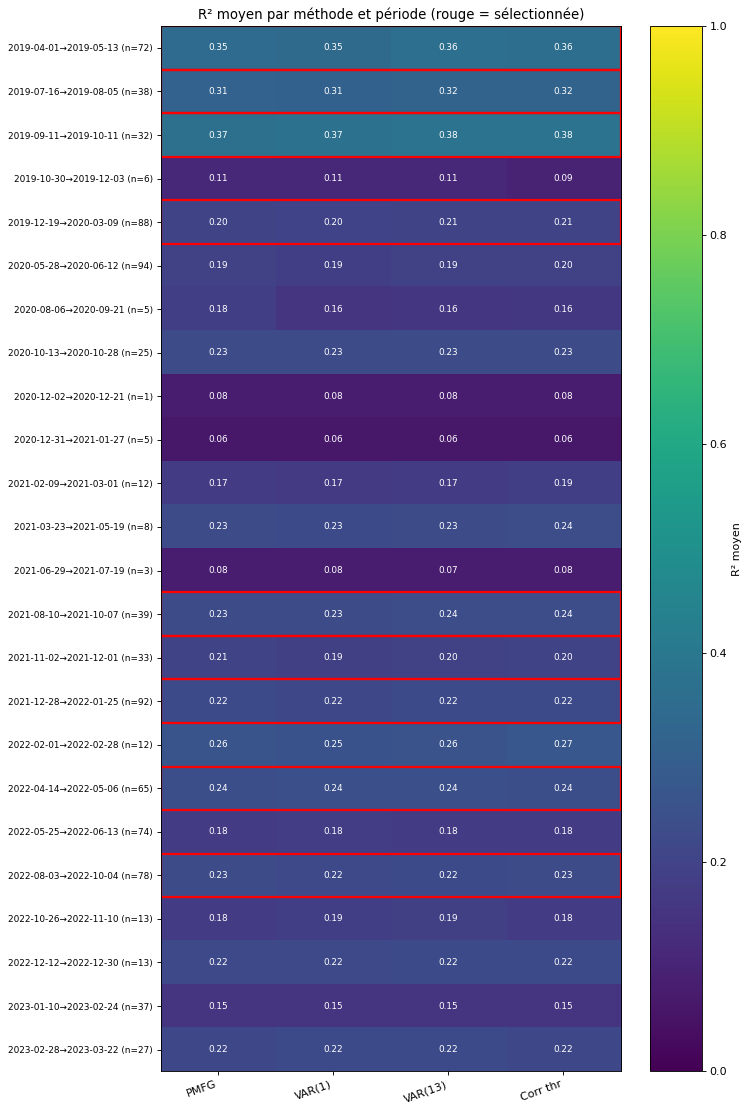

In [60]:
# ── R² moyen par période et par méthode + sélection (n > 30, R² > 0.2) ──────
N_MIN, R2_PERIOD = 30, 0.2
def _compute_period_data():
    return {(pa, pb): fits_for(pa, pb) for (pa, pb) in intervals_chrono}

_sig = make_sig(data, crisis_map, E_daily_all, intervals_chrono, A_sis,
                B_fit, R_fit, T_long, tol_eq, SMOOTH2, MIN_LEN, MIN_GAIN, SIS_MODELS, N)
period_data = disk_cache('period_data_signed', _sig, _compute_period_data)

rows = []
mean_r2 = np.full((len(intervals_chrono), len(SIS_MODELS)), np.nan)
for pi, (pa, pb) in enumerate(intervals_chrono):
    cache, fits = period_data[(pa, pb)]
    for j, m in enumerate(SIS_MODELS):
        r2s = [fits[m][1][gi]['r2'] for gi in fits[m][1]]
        mean_r2[pi, j] = np.mean(r2s) if r2s else np.nan
    rows.append(f'{all_days[pa]}→{all_days[pb]} (n={len(cache)})')
    print(f'[{pi}] {rows[-1]} : ' +
          ', '.join(f'{m} {mean_r2[pi, j]:.2f}' for j, m in enumerate(SIS_MODELS)))

r2_mean_df = pd.DataFrame(mean_r2, index=rows, columns=SIS_MODELS)

selected = []
for pi, (pa, pb) in enumerate(intervals_chrono):
    n = len(period_data[(pa, pb)][0])
    if n > N_MIN and np.nanmax(mean_r2[pi]) > R2_PERIOD:
        selected.append((pa, pb))
print(f'\n{len(selected)} période(s) sélectionnée(s) (n > {N_MIN}, R² > {R2_PERIOD}) :')
for (pa, pb) in selected:
    print(f'  {all_days[pa]} → {all_days[pb]}')

# Heatmap R² moyen (périodes x matrices), périodes sélectionnées encadrées
fig, ax = plt.subplots(figsize=(1.6 * len(SIS_MODELS) + 3, 0.5 * len(rows) + 2))
im = ax.imshow(mean_r2, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(SIS_MODELS))); ax.set_xticklabels(SIS_MODELS, rotation=20, ha='right')
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=8)
sel_idx = {intervals_chrono.index(p) for p in selected}
for i in range(len(rows)):
    for j in range(len(SIS_MODELS)):
        v = mean_r2[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.6 else 'black', fontsize=8)
    if i in sel_idx:
        ax.add_patch(plt.Rectangle((-0.5, i - 0.5), len(SIS_MODELS), 1,
                                   fill=False, edgecolor='red', linewidth=2))
cb = fig.colorbar(im, ax=ax); cb.set_label('R² moyen')
ax.set_title('R² moyen par méthode et période (rouge = sélectionnée)', fontsize=12)
plt.tight_layout(); plt.show()

# ── Affichage : ne tracer qu'UNE periode dans les cellules de courbes ────────
#    SHOW_PERIOD = index de la periode a tracer (0 = 1re, 2 = 3e ...) ; None = toutes.
#    N'affecte QUE courbes / spaghettis / scatter ; les analyses agregees
#    (recurrence, pentes, jours de crise) gardent toutes les periodes.
SHOW_PERIOD = 2
def _disp(sel):
    return sel if SHOW_PERIOD is None else sel[SHOW_PERIOD:SHOW_PERIOD + 1]

9 période(s) retenue(s) :
                               PMFG  VAR(1)  VAR(13)  Corr thr
2019-04-01→2019-05-13 (n=72)  0.350   0.347    0.364     0.363
2019-07-16→2019-08-05 (n=38)  0.315   0.310    0.319     0.318
2019-09-11→2019-10-11 (n=32)  0.369   0.374    0.379     0.381
2019-12-19→2020-03-09 (n=88)  0.205   0.202    0.206     0.206
2021-08-10→2021-10-07 (n=39)  0.231   0.227    0.238     0.235
2021-11-02→2021-12-01 (n=33)  0.206   0.191    0.198     0.203
2021-12-28→2022-01-25 (n=92)  0.224   0.215    0.223     0.225
2022-04-14→2022-05-06 (n=65)  0.240   0.243    0.243     0.240
2022-08-03→2022-10-04 (n=78)  0.231   0.221    0.224     0.230


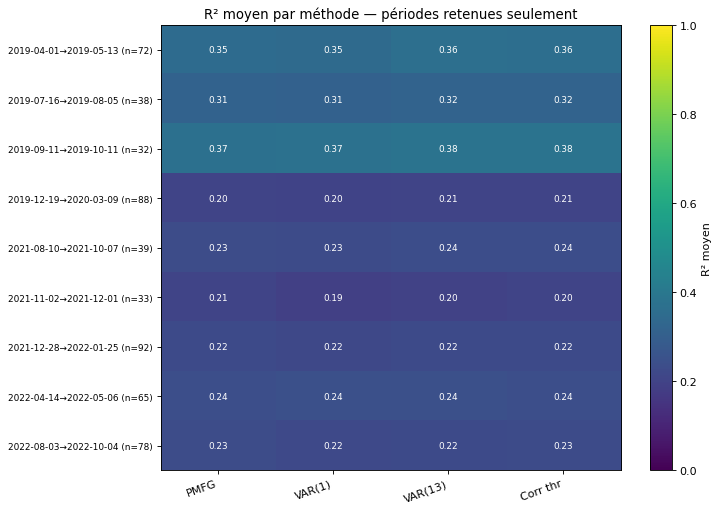

In [61]:
# ── R² moyen — TABLEAU restreint aux périodes retenues ──────────────────────
# Reprend mean_r2 / rows / selected de la cellule précédente, mais ne garde que
# les périodes sélectionnées (n > N_MIN et R² > R2_PERIOD).
sel_rows = [intervals_chrono.index(p) for p in selected]
r2_sel_df = pd.DataFrame(mean_r2[sel_rows], index=[rows[i] for i in sel_rows],
                         columns=SIS_MODELS)
print(f'{len(sel_rows)} période(s) retenue(s) :')
print(r2_sel_df.round(3).to_string())

if sel_rows:
    sub = mean_r2[sel_rows]
    fig, ax = plt.subplots(figsize=(1.6 * len(SIS_MODELS) + 3, 0.5 * len(sel_rows) + 2))
    im = ax.imshow(sub, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(SIS_MODELS))); ax.set_xticklabels(SIS_MODELS, rotation=20, ha='right')
    ax.set_yticks(range(len(sel_rows))); ax.set_yticklabels([rows[i] for i in sel_rows], fontsize=8)
    for i in range(len(sel_rows)):
        for j in range(len(SIS_MODELS)):
            v = sub[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v < 0.6 else 'black', fontsize=8)
    cb = fig.colorbar(im, ax=ax); cb.set_label('R² moyen')
    ax.set_title('R² moyen par méthode — périodes retenues seulement', fontsize=12)
    plt.tight_layout(); plt.show()

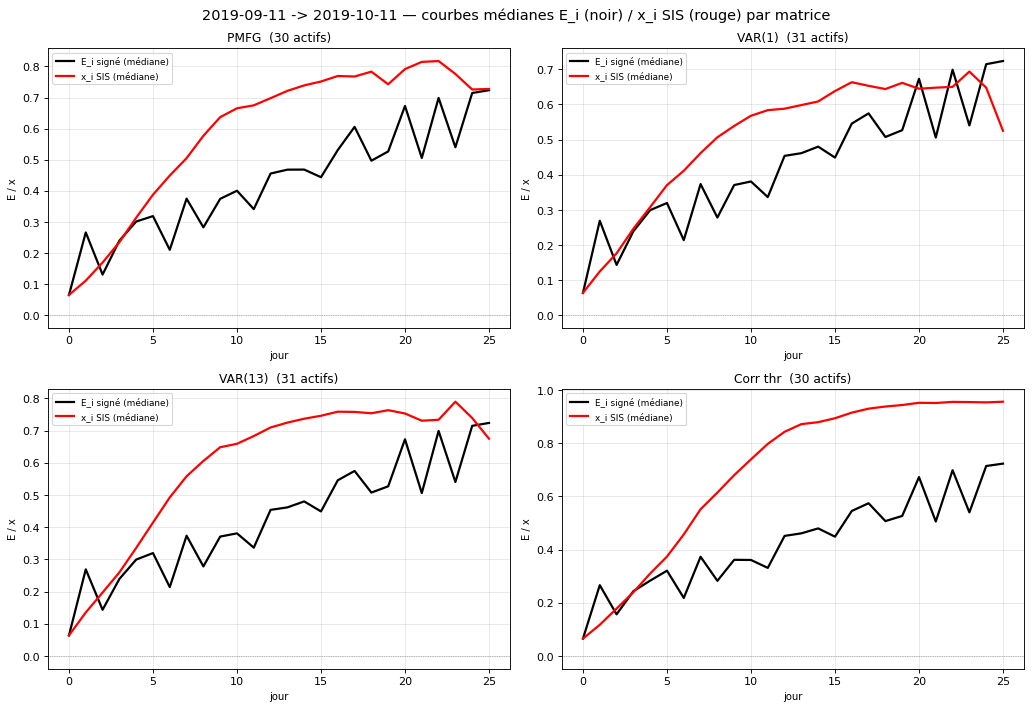

In [62]:
# ── Courbes MÉDIANES sur les périodes sélectionnées ─────────────────────────
# Pour chaque période et chaque matrice : médiane (sur les actifs retenus) de
# E_i signé (noir) et de x_i SIS (rouge), alignées par jour relatif.
def _ok_r2(fits, m, gi):
    sl = fits[m][1]
    return gi in sl and sl[gi]['r2'] >= R2_MIN

def _median_stack(series_list):
    """Médiane par jour relatif de séries de longueurs variables (nanmédiane)."""
    if not series_list:
        return np.array([])
    L = max(len(v) for v in series_list)
    M = np.full((len(series_list), L), np.nan)
    for r, v in enumerate(series_list):
        M[r, :len(v)] = v
    return np.nanmedian(M, axis=0)

def median_period(pa, pb, cache, fits):
    """Courbes médianes E_i (noir) / x_i SIS (rouge) par matrice."""
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    assets = [gi for gi in cache if any(_ok_r2(fits, m, gi) for m in SIS_MODELS)]
    if not assets:
        print(f'{lab} : aucun actif retenu.'); return
    fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        kept = [gi for gi in assets if _ok_r2(fits, m, gi)]
        Es = [fits[m][0][gi][0] for gi in kept]   # E_i (peut contenir des NaN)
        Xs = [fits[m][0][gi][1] for gi in kept]   # x_i SIS
        med_E, med_X = _median_stack(Es), _median_stack(Xs)
        if len(med_E):
            ax.plot(np.arange(len(med_E)), med_E, color='black', linewidth=2.0,
                    label='E_i signé (médiane)')
            ax.plot(np.arange(len(med_X)), med_X, color='red', linewidth=2.0,
                    label='x_i SIS (médiane)')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{m}  ({len(kept)} actifs)', fontsize=11)
        ax.set_xlabel('jour', fontsize=9); ax.set_ylabel('E / x', fontsize=9)
        ax.grid(alpha=0.3)
        if kept: ax.legend(fontsize=8, loc='best')
    plt.suptitle(f'{lab} — courbes médianes E_i (noir) / x_i SIS (rouge) par matrice',
                 fontsize=13)
    plt.tight_layout(); plt.show()

for (pa, pb) in _disp(selected):
    median_period(pa, pb, *period_data[(pa, pb)])

In [63]:
# ── DEFINITIONS PARTAGEES (moyennes) — NE PAS SUPPRIMER ─────────────────────
# _mean_stack, mean_period, mean_vs_median_period : requises par la section |C|
# (Courbes moyennes / Mediane vs moyenne) et par les cellules de balayage /
# courbes-temps. Defs seules (les anciennes cellules de COURBES les portaient).

# ── Courbes MOYENNES sur les périodes sélectionnées ─────────────────────────
# Idem que les courbes médianes, mais avec la MOYENNE (sur les actifs retenus)
# de E_i signé (noir) et de x_i SIS (rouge), alignées par jour relatif.
def _mean_stack(series_list):
    """Moyenne par jour relatif de séries de longueurs variables (nanmoyenne)."""
    if not series_list:
        return np.array([])
    L = max(len(v) for v in series_list)
    M = np.full((len(series_list), L), np.nan)
    for r, v in enumerate(series_list):
        M[r, :len(v)] = v
    return np.nanmean(M, axis=0)

def mean_period(pa, pb, cache, fits):
    """Courbes moyennes E_i (noir) / x_i SIS (rouge) par matrice."""
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    assets = [gi for gi in cache if any(_ok_r2(fits, m, gi) for m in SIS_MODELS)]
    if not assets:
        print(f'{lab} : aucun actif retenu.'); return
    fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        kept = [gi for gi in assets if _ok_r2(fits, m, gi)]
        Es = [fits[m][0][gi][0] for gi in kept]
        Xs = [fits[m][0][gi][1] for gi in kept]
        mean_E, mean_X = _mean_stack(Es), _mean_stack(Xs)
        if len(mean_E):
            ax.plot(np.arange(len(mean_E)), mean_E, color='black', linewidth=2.0,
                    label='E_i signé (moyenne)')
            ax.plot(np.arange(len(mean_X)), mean_X, color='red', linewidth=2.0,
                    label='x_i SIS (moyenne)')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{m}  ({len(kept)} actifs)', fontsize=11)
        ax.set_xlabel('jour', fontsize=9); ax.set_ylabel('E / x', fontsize=9)
        ax.grid(alpha=0.3)
        if kept: ax.legend(fontsize=8, loc='best')
    plt.suptitle(f'{lab} — courbes moyennes E_i (noir) / x_i SIS (rouge) par matrice',
                 fontsize=13)
    plt.tight_layout(); plt.show()


# ── Comparaison moyenne vs médiane sur les périodes sélectionnées ───────────
# Par matrice : E_i (noir) et x_i SIS (rouge), médiane en trait plein, moyenne
# en pointillés. Réutilise _ok_r2 / _median_stack / _mean_stack.
def mean_vs_median_period(pa, pb, cache, fits):
    """Superpose médiane (plein) et moyenne (pointillés) de E_i et x_i."""
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    assets = [gi for gi in cache if any(_ok_r2(fits, m, gi) for m in SIS_MODELS)]
    if not assets:
        print(f'{lab} : aucun actif retenu.'); return
    fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        kept = [gi for gi in assets if _ok_r2(fits, m, gi)]
        Es = [fits[m][0][gi][0] for gi in kept]
        Xs = [fits[m][0][gi][1] for gi in kept]
        mE, aE = _median_stack(Es), _mean_stack(Es)
        mX, aX = _median_stack(Xs), _mean_stack(Xs)
        if len(mE):
            ax.plot(np.arange(len(mE)), mE, color='black', lw=2.0, label='E_i médiane')
            ax.plot(np.arange(len(aE)), aE, color='black', lw=1.6, ls='--', label='E_i moyenne')
            ax.plot(np.arange(len(mX)), mX, color='red', lw=2.0, label='x_i médiane')
            ax.plot(np.arange(len(aX)), aX, color='red', lw=1.6, ls='--', label='x_i moyenne')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{m}  ({len(kept)} actifs)', fontsize=11)
        ax.set_xlabel('jour', fontsize=9); ax.set_ylabel('E / x', fontsize=9)
        ax.grid(alpha=0.3)
        if kept: ax.legend(fontsize=8, loc='best')
    plt.suptitle(f'{lab} — médiane (plein) vs moyenne (pointillés), E_i noir / x_i rouge',
                 fontsize=13)
    plt.tight_layout(); plt.show()


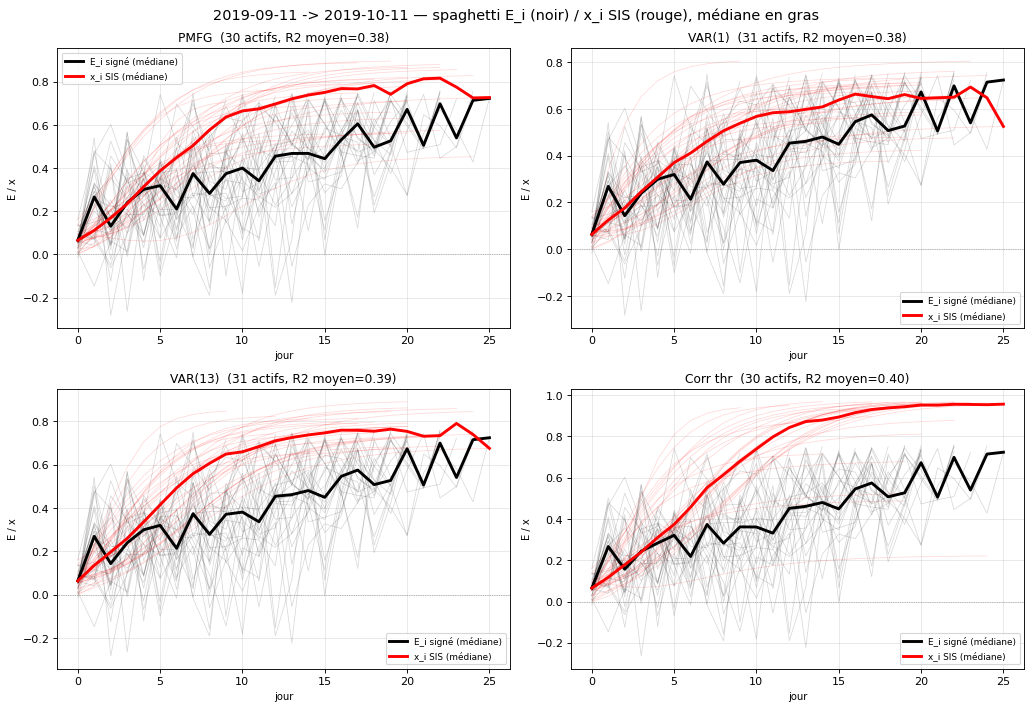

In [64]:
# ── Spaghettis sur les périodes sélectionnées ───────────────────────────────
# Par matrice : toutes les courbes des actifs retenus superposées — E_i signé
# (noir) et x_i SIS (rouge), avec transparence. Réutilise _ok_r2 / period_data.
def spaghetti_period(pa, pb, cache, fits):
    """Spaghetti par matrice (E_i noir / x_i rouge) des actifs retenus."""
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    assets = [gi for gi in cache if any(_ok_r2(fits, m, gi) for m in SIS_MODELS)]
    if not assets:
        print(f'{lab} : aucun actif retenu.'); return
    fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        kept = [gi for gi in assets if _ok_r2(fits, m, gi)]
        Es, Xs = [], []
        for gi in kept:
            E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
            ax.plot(np.arange(len(E_i))[ok], E_i[ok], color='black', alpha=0.15, linewidth=0.7)
            ax.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, linewidth=0.7)
            Es.append(E_i); Xs.append(x_traj)
        med_E, med_X = _median_stack(Es), _median_stack(Xs)   # mediane bien visible par-dessus
        if len(med_E):
            ax.plot(np.arange(len(med_E)), med_E, color='black', linewidth=2.6,
                    label='E_i signé (médiane)')
            ax.plot(np.arange(len(med_X)), med_X, color='red', linewidth=2.6,
                    label='x_i SIS (médiane)')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        r2m = np.mean([fits[m][1][gi]['r2'] for gi in kept]) if kept else np.nan
        ax.set_title(f'{m}  ({len(kept)} actifs, R2 moyen={r2m:.2f})', fontsize=11)
        ax.set_xlabel('jour', fontsize=9); ax.set_ylabel('E / x', fontsize=9)
        ax.grid(alpha=0.3)
        if kept: ax.legend(fontsize=8, loc='best')
    plt.suptitle(f'{lab} — spaghetti E_i (noir) / x_i SIS (rouge), médiane en gras', fontsize=13)
    plt.tight_layout(); plt.show()

for (pa, pb) in _disp(selected):
    spaghetti_period(pa, pb, *period_data[(pa, pb)])

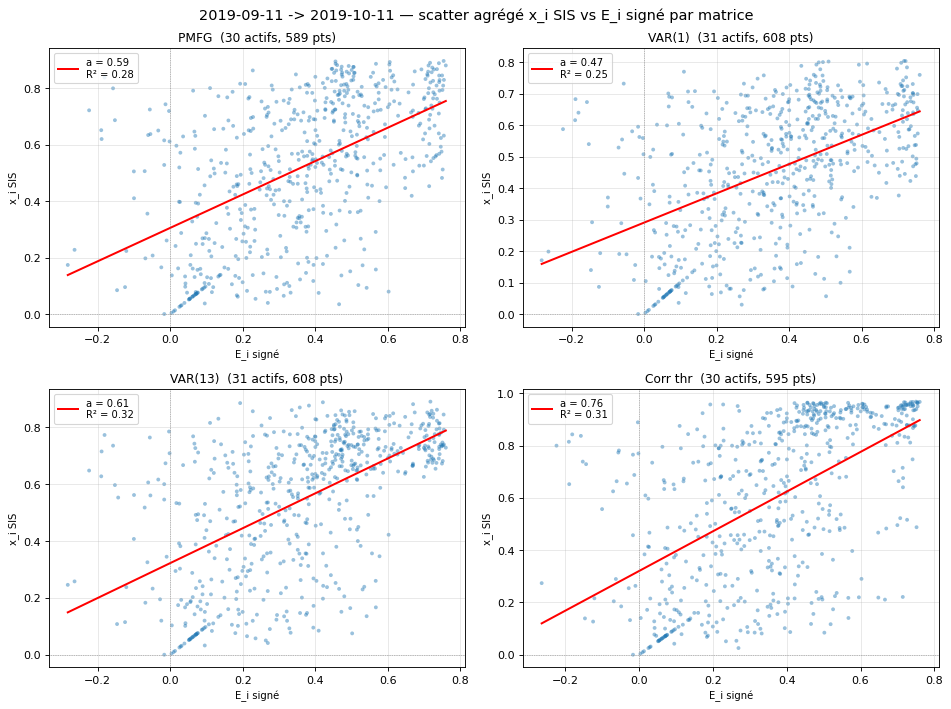

In [65]:
# ── Scatter agrégé par période et par matrice ───────────────────────────────
# Pour chaque période retenue : une grille 2x2 (une matrice par sous-plot). On
# met en commun les points (E_i signé, x_i SIS) des actifs retenus et on ajuste
# une régression globale (pente + R² agrégé). Réutilise _ok_r2 / period_data.
def scatter_period(pa, pb, cache, fits):
    """Scatter agrégé x_i SIS vs E_i signé, un sous-plot par matrice."""
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    assets = [gi for gi in cache if any(_ok_r2(fits, m, gi) for m in SIS_MODELS)]
    if not assets:
        print(f'{lab} : aucun actif retenu.'); return
    fig, axes = plt.subplots(2, 2, figsize=(12, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        kept = [gi for gi in assets if _ok_r2(fits, m, gi)]
        Eall, Xall = [], []
        for gi in kept:
            E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
            Eall.append(E_i[ok]); Xall.append(x_traj[ok])
        if Eall:
            Eall = np.concatenate(Eall); Xall = np.concatenate(Xall)
            ax.scatter(Eall, Xall, s=12, color='#1f77b4', alpha=0.45, edgecolors='none')
            if len(Eall) >= 3:
                f = linregress(Eall, Xall); xs = np.linspace(Eall.min(), Eall.max(), 50)
                ax.plot(xs, f.slope * xs + f.intercept, color='red', linewidth=1.8,
                        label=f'a = {f.slope:.2f}\nR² = {f.rvalue ** 2:.2f}')
                ax.legend(fontsize=9, loc='best')
        ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{m}  ({len(kept)} actifs, {len(Eall) if len(Eall) else 0} pts)', fontsize=11)
        ax.set_xlabel('E_i signé', fontsize=9); ax.set_ylabel('x_i SIS', fontsize=9)
        ax.grid(alpha=0.3)
    plt.suptitle(f'{lab} — scatter agrégé x_i SIS vs E_i signé par matrice', fontsize=13)
    plt.tight_layout(); plt.show()

for (pa, pb) in _disp(selected):
    scatter_period(pa, pb, *period_data[(pa, pb)])

### Sensibilité du SIS↔E_i : moyenne sur tous les actifs de la période

Sur la période affichée, pour chaque valeur du paramètre on **moyenne la trajectoire `x_i(t)` du SIS sur tous les actifs** de la période (couleur = paramètre) face à `E_i` moyen empirique, puis on trace l'**équilibre x\* moyen**. D'abord le **lag du VAR** (quelques lags < 13 puis les multiples 13, 26, 39), puis le **seuil q de |C|** (balayage dense).

2019-09-11 -> 2019-10-11 : moyenne sur 32 actifs


[cache] OK  lagmean_2019-09-11  (rechargé depuis .cache/periods_analysis/lagmean_2019-09-11.8a5a8c9d101fe82f.pkl)


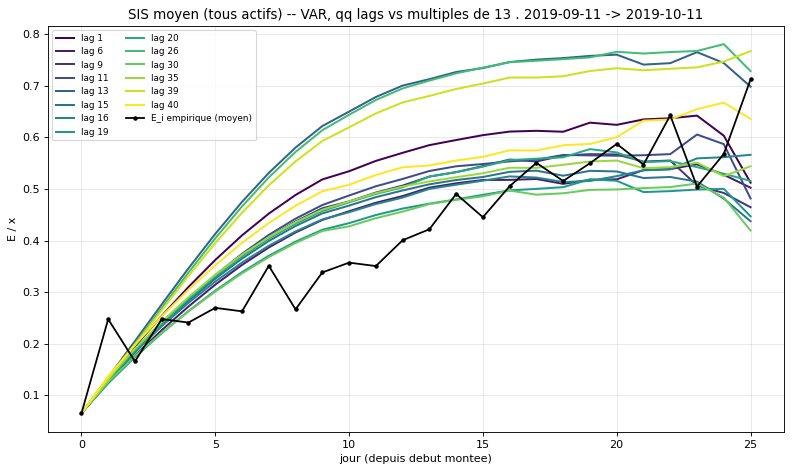

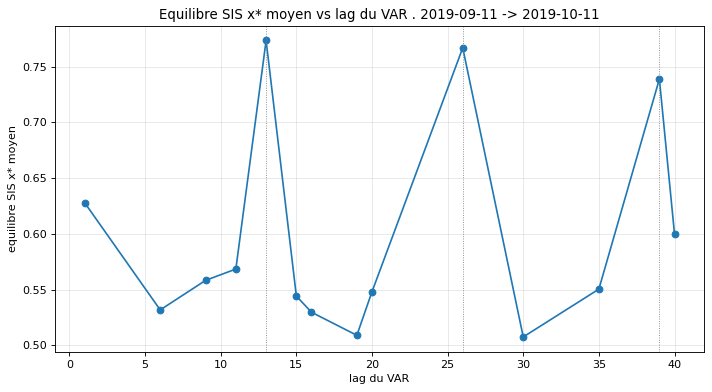

In [66]:
# ── Sensibilite au LAG du VAR : SIS moyen sur TOUS les actifs vs E_i ─────────
# Pour chaque lag : trajectoire x_i(t) SIS moyennee sur tous les actifs de la
# periode (couleur = lag) face a E_i moyen, puis equilibre x* moyen vs lag.
R_arr = data.values
LAGS  = np.array([1, 6,9, 11, 13,15,16,19,20, 26,30,35,39, 40])   # qq lags < 13, puis 3 multiples de 13

def var_matrix(lag):
    """Matrice VAR(lag) prete pour le SIS (meme construction que A_sis['VAR(.)'])."""
    Av = np.abs(fit_var(R_arr, int(lag)).T); np.fill_diagonal(Av, 0)
    return prepare_for_sis(Av)

def sis_run(cache, gi, A):
    """Trajectoire x_i SIS + equilibre x* en un seul passage (dynamique bornee)."""
    d = cache[gi]; x0, n = d['x0'], d['n_days']
    sol_eq = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A, B_fit, R_fit),
                       method='LSODA', rtol=1e-6, atol=1e-9)
    x_eq = sol_eq.y[gi, -1]
    tp = np.linspace(1e-3, T_long, 5000)
    sp = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A, B_fit, R_fit),
                   t_eval=tp, method='LSODA', rtol=1e-6, atol=1e-9)
    above = np.where(sp.y[gi] >= (1 - tol_eq) * x_eq)[0]
    Tc = float(tp[above[0]]) if len(above) else T_long
    s = solve_ivp(ode_sis_bounded, (0, Tc), x0, args=(A, B_fit, R_fit),
                  t_eval=np.linspace(0, Tc, n), method='LSODA')
    return np.clip(s.y[gi], 1e-8, 1 - 1e-8), float(x_eq)

def sweep_mean(cache, mats):
    """{cle: A} -> {cle: (trajectoire moyennee sur les actifs, x* moyen)}."""
    out = {}
    for k, A in mats.items():
        trajs, xst = zip(*(sis_run(cache, gi, A) for gi in cache))
        out[k] = (_mean_stack(list(trajs)), float(np.mean(xst)))
    return out

for (pa, pb) in _disp(selected):
    cache = period_data[(pa, pb)][0]; lab = f'{all_days[pa]} -> {all_days[pb]}'
    print(f'{lab} : moyenne sur {len(cache)} actifs')
    E_mean = _mean_stack([cache[gi]['E_i'] for gi in cache]); t = np.arange(len(E_mean))
    mats = {int(L): var_matrix(L) for L in LAGS}
    sig  = make_sig(cache, mats, B_fit, R_fit, T_long, tol_eq)
    res  = disk_cache(f'lagmean_{all_days[pa]}', sig,
                      lambda c=cache, mm=mats: sweep_mean(c, mm))

    colors = plt.cm.viridis(np.linspace(0, 1, len(LAGS)))
    fig, ax = plt.subplots(figsize=(10, 6))
    for col, L in zip(colors, LAGS):
        ax.plot(t, res[int(L)][0], color=col, lw=1.8, label=f'lag {L}')
    ax.plot(t, E_mean, color='black', marker='o', ms=3, lw=1.6,
            label='E_i empirique (moyen)', zorder=5)
    ax.set_xlabel('jour (depuis debut montee)'); ax.set_ylabel('E / x')
    ax.set_title(f'SIS moyen (tous actifs) -- VAR, qq lags vs multiples de 13 . {lab}')
    ax.legend(fontsize=8, loc='best', ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(LAGS, [res[int(L)][1] for L in LAGS], 'o-', color='#1f77b4')
    for L in (13, 26, 39):
        ax.axvline(L, color='gray', ls=':', lw=0.8)   # multiples de 13
    ax.set_xlabel('lag du VAR'); ax.set_ylabel('equilibre SIS x* moyen')
    ax.set_title(f'Equilibre SIS x* moyen vs lag du VAR . {lab}')
    ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


2019-09-11 -> 2019-10-11 : moyenne sur 32 actifs, 50 seuils
[cache] OK  qmean_2019-09-11  (rechargé depuis .cache/periods_analysis/qmean_2019-09-11.22a6d79ec3068174.pkl)


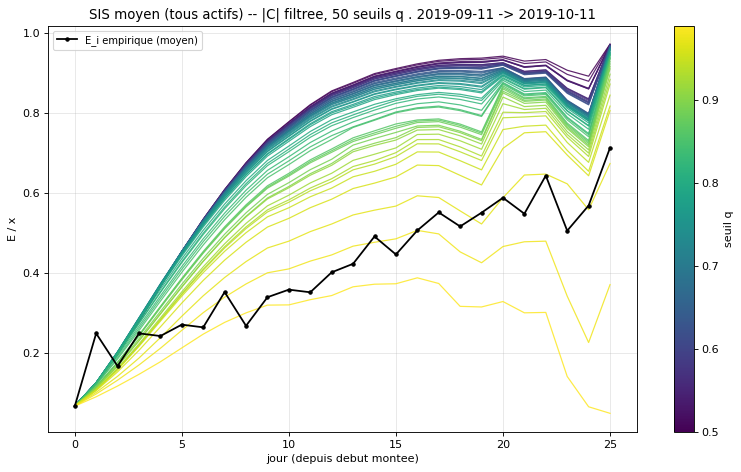

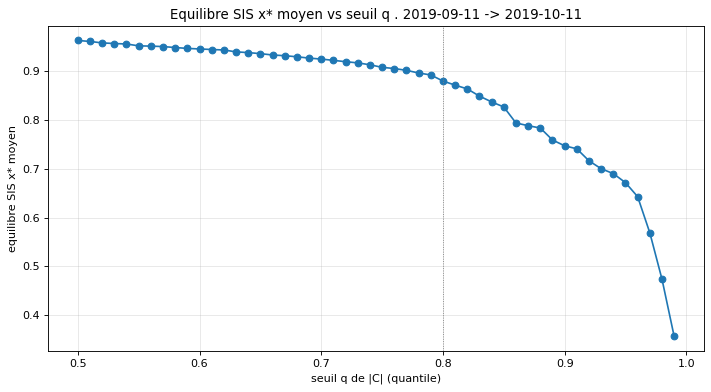

In [67]:
# ── Sensibilite au SEUIL q de |C| : SIS moyen sur TOUS les actifs vs E_i ─────
# Balayage dense de q : trajectoire SIS moyennee sur tous les actifs (couleur = q)
# face a E_i moyen, puis equilibre x* moyen vs q. Reutilise sis_run / sweep_mean.
Q_SWEEP = np.linspace(0.50, 0.99, 50)

for (pa, pb) in _disp(selected):
    cache = period_data[(pa, pb)][0]; lab = f'{all_days[pa]} -> {all_days[pb]}'
    print(f'{lab} : moyenne sur {len(cache)} actifs, {len(Q_SWEEP)} seuils')
    E_mean = _mean_stack([cache[gi]['E_i'] for gi in cache]); t = np.arange(len(E_mean))
    mats = {i: build_filtered_corr(q) for i, q in enumerate(Q_SWEEP)}
    sig  = make_sig(cache, mats, B_fit, R_fit, T_long, tol_eq)
    res  = disk_cache(f'qmean_{all_days[pa]}', sig,
                      lambda c=cache, mm=mats: sweep_mean(c, mm))

    cmap = plt.cm.viridis; norm = plt.Normalize(Q_SWEEP.min(), Q_SWEEP.max())
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, q in enumerate(Q_SWEEP):
        ax.plot(t, res[i][0], color=cmap(norm(q)), lw=1.1, alpha=0.85)
    ax.plot(t, E_mean, color='black', marker='o', ms=3, lw=1.6,
            label='E_i empirique (moyen)', zorder=5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=ax).set_label('seuil q')
    ax.set_xlabel('jour (depuis debut montee)'); ax.set_ylabel('E / x')
    ax.set_title(f'SIS moyen (tous actifs) -- |C| filtree, {len(Q_SWEEP)} seuils q . {lab}')
    ax.legend(fontsize=9, loc='best'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(Q_SWEEP, [res[i][1] for i in range(len(Q_SWEEP))], 'o-', color='#1f77b4')
    ax.axvline(0.80, color='gray', ls=':', lw=0.8)   # seuil de reference 'Corr thr'
    ax.set_xlabel('seuil q de |C| (quantile)'); ax.set_ylabel('equilibre SIS x* moyen')
    ax.set_title(f'Equilibre SIS x* moyen vs seuil q . {lab}')
    ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


132 actifs retenus au moins une fois sur 9 périodes.
97 actifs redondants (présents dans >= 2 périodes) :
ADI[Information Technology](6), GS[Financials](6), INTC[Information Technology](6), AMAT[Information Technology](5), AMZN[Consumer Discretionary](5), CB[Financials](5), CSCO[Information Technology](5), HON[Consumer Staples](5), IBM[Information Technology](5), LIN[Materials](5), MMC[Financials](5), TJX[Consumer Discretionary](5), AAPL[Information Technology](4), AXP[Financials](4), BLK[Financials](4), BSX[Healthcare](4), CAT[Industrials](4), CI[Healthcare](4), CVS[Healthcare](4), ETN[Industrials](4), HD[Consumer Discretionary](4), ISRG[Healthcare](4), ITW[Consumer Staples](4), LOW[Consumer Discretionary](4), MA[Information Technology](4), META[Information Technology](4), SAP[Information Technology](4), SCHW[Financials](4), V[Information Technology](4), XOM[Energy](4), ADP[Information Technology](3), ALV[Consumer Discretionary](3), AVGO[Information Technology](3), BAC[Financials](3),

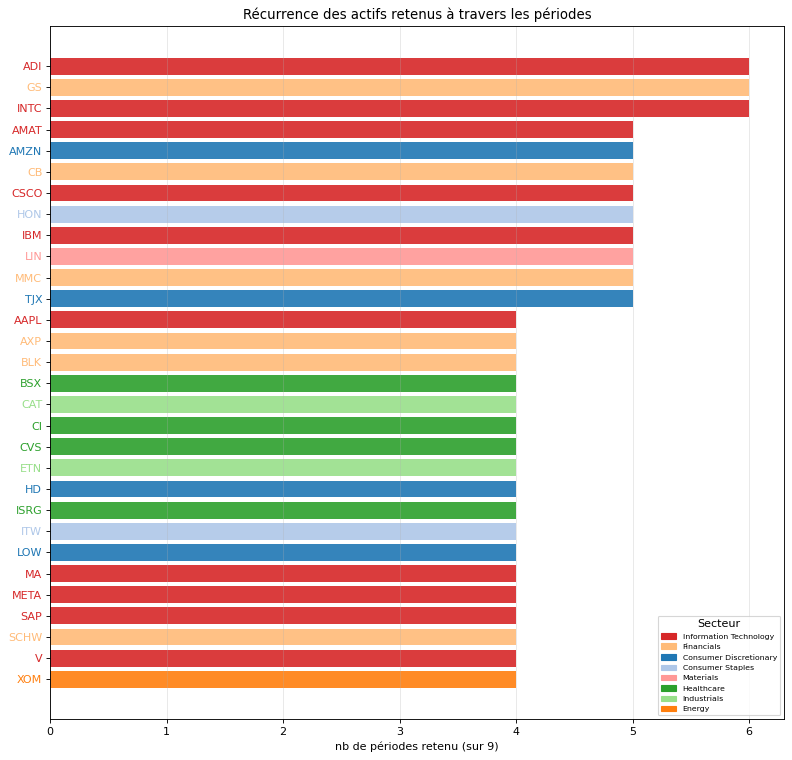

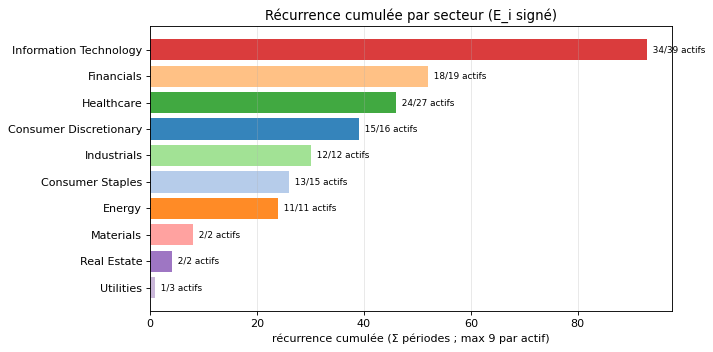

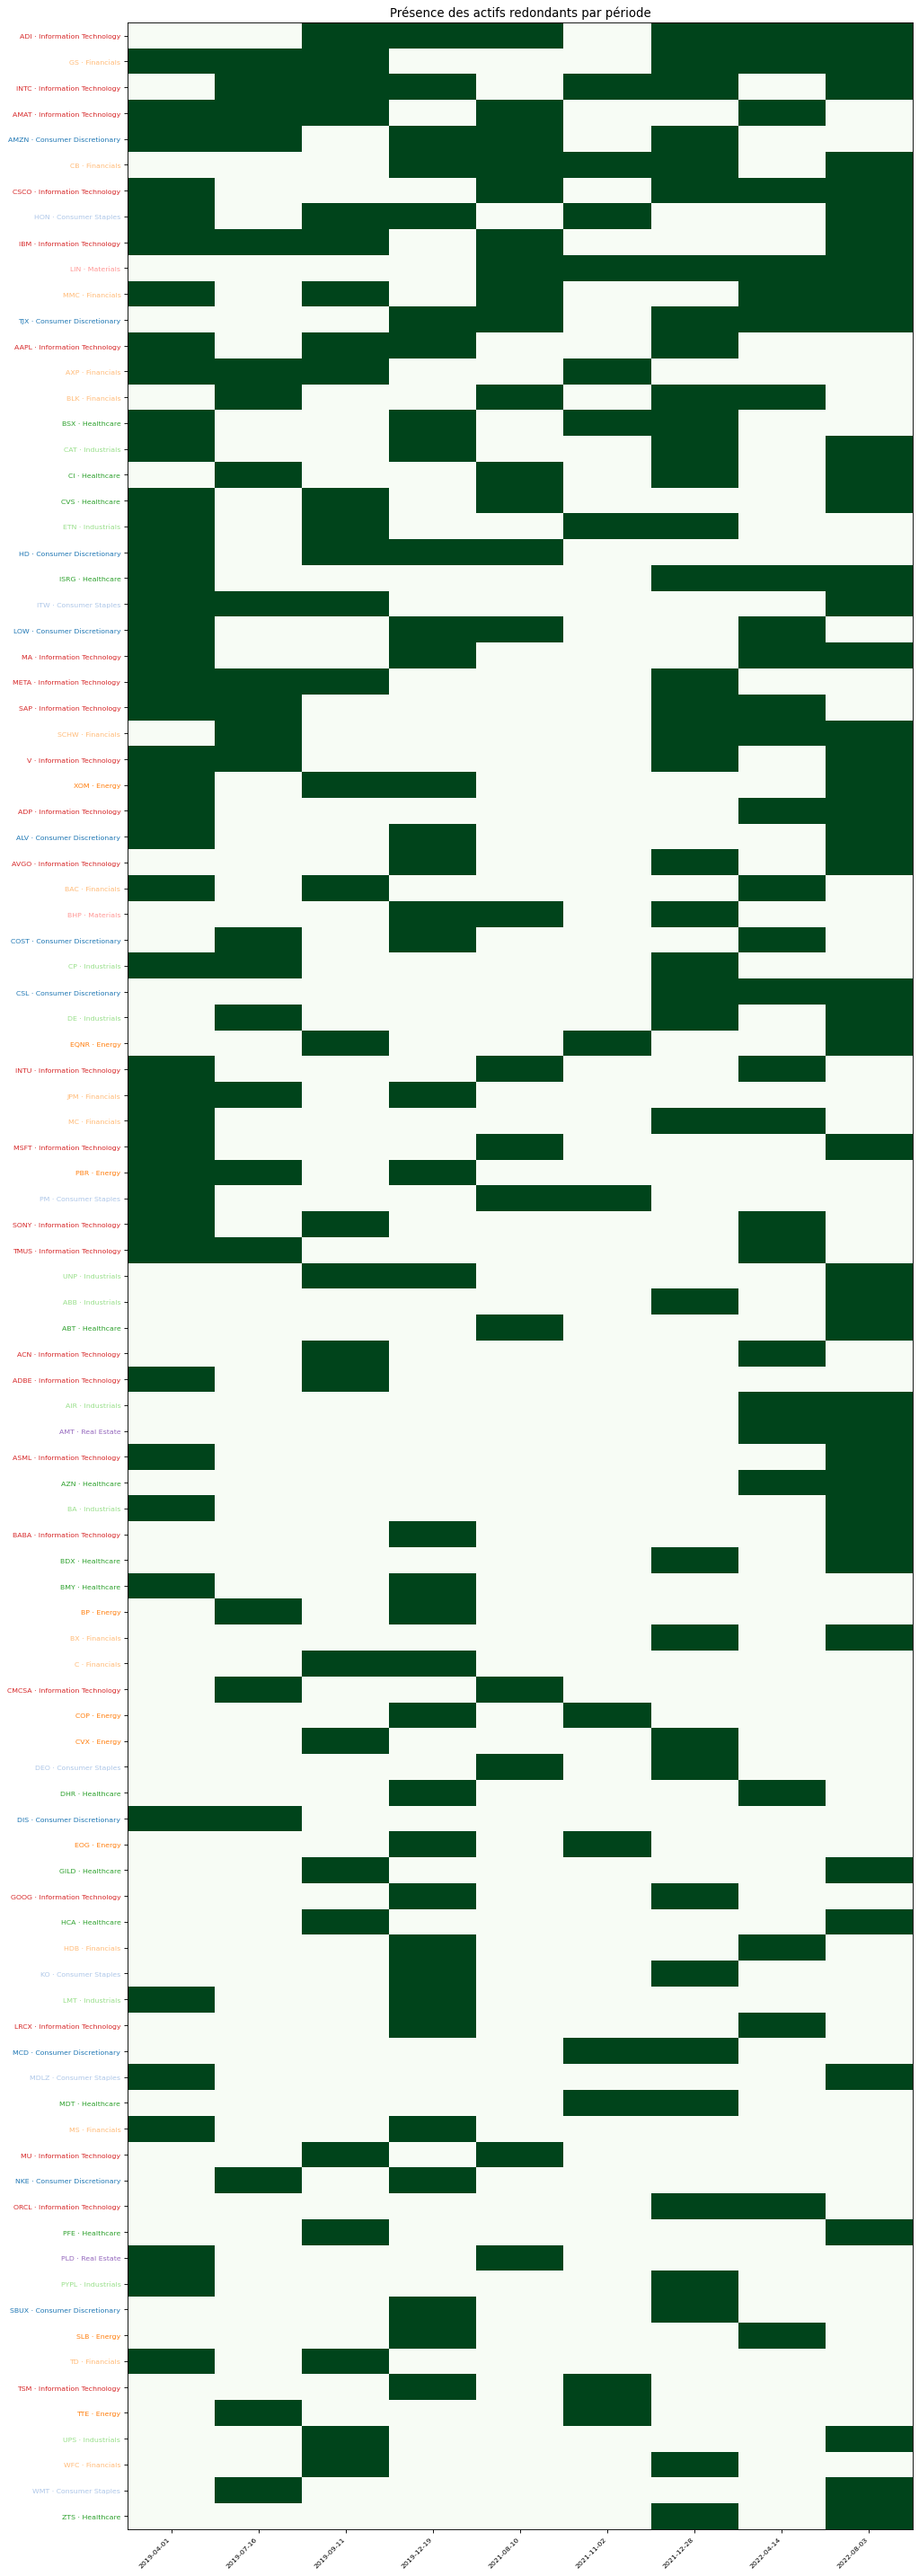

In [68]:
# ── Récurrence des actifs retenus à travers les périodes (redondances) ──────
# Pour chaque période sélectionnée : actifs retenus (R² >= R2_MIN pour >= 1
# matrice). On compte dans combien de périodes chaque actif apparaît -> les plus
# fréquents sont les 'redondants'. Secteurs affichés pour repérer des patterns.
from collections import Counter

per_period_assets = {}
cnt = Counter()
for (pa, pb) in selected:
    cache, fits = period_data[(pa, pb)]
    kept = [gi for gi in cache if any(_ok_r2(fits, m, gi) for m in SIS_MODELS)]
    per_period_assets[(pa, pb)] = kept
    for gi in kept:
        cnt[gi] += 1

nP = len(selected)
order = sorted(cnt, key=lambda gi: (-cnt[gi], asset_names[gi]))
recur_df = pd.DataFrame({
    'actif':      [asset_names[gi] for gi in order],
    'secteur':    [gi_sector(gi) for gi in order],
    'n_periodes': [cnt[gi] for gi in order],
    'part':       [f'{cnt[gi]}/{nP}' for gi in order],
})
print(f'{len(order)} actifs retenus au moins une fois sur {nP} périodes.')
redond = [gi for gi in order if cnt[gi] >= 2]
print(f'{len(redond)} actifs redondants (présents dans >= 2 périodes) :')
print(', '.join(f'{asset_names[gi]}[{gi_sector(gi)}]({cnt[gi]})' for gi in redond) or '(aucun)')
print(); print(recur_df.head(25).to_string(index=False))

# ── Barres : récurrence par actif (top 30), colorées par secteur ────────────
barh_by_sector(order[:30], cnt,
               'Récurrence des actifs retenus à travers les périodes',
               f'nb de périodes retenu (sur {nP})')

# ── Récurrence agrégée par secteur (vue 'pattern' globale) ──────────────────
sector_recurrence_plot(cnt, nP, 'Récurrence cumulée par secteur (E_i signé)')

# ── Heatmap présence actif (redondant) × période, labels colorés par secteur ─
if redond:
    P = np.zeros((len(redond), nP))
    for j, (pa, pb) in enumerate(selected):
        for i, gi in enumerate(redond):
            P[i, j] = gi in per_period_assets[(pa, pb)]
    fig, ax = plt.subplots(figsize=(1.1 * nP + 3, 0.35 * len(redond) + 2))
    ax.imshow(P, aspect='auto', cmap='Greens', vmin=0, vmax=1)
    ax.set_xticks(range(nP))
    ax.set_xticklabels([f'{all_days[a]}' for (a, b) in selected], rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(redond)))
    ax.set_yticklabels([f'{asset_names[gi]} · {gi_sector(gi)}' for gi in redond], fontsize=7)
    for tick, gi in zip(ax.get_yticklabels(), redond):
        tick.set_color(gi_color(gi))
    ax.set_title('Présence des actifs redondants par période')
    plt.tight_layout(); plt.show()


Pente a (x_i SIS / E_i signé) — actifs retenus, périodes sélectionnées :
          pente_moy  ecart_type  n_actifs
PMFG          0.522       0.185       307
VAR(1)        0.426       0.147       302
VAR(13)       0.557       0.167       305
Corr thr      0.693       0.245       305


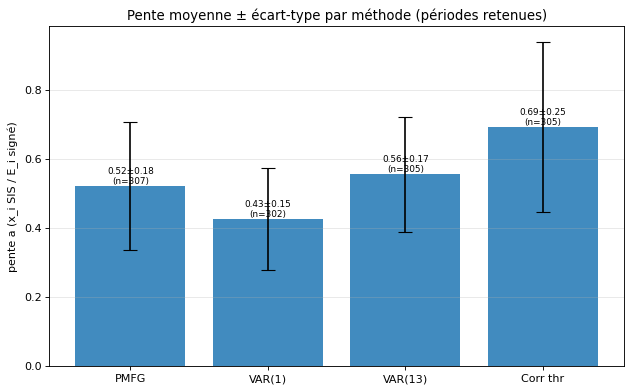

In [69]:
# ── Pente moyenne ± écart-type par méthode (sur les périodes retenues) ──────
# On regroupe les pentes a (régression x_i SIS vs E_i signé) des actifs RETENUS
# (R² >= R2_MIN) sur toutes les périodes sélectionnées, par matrice. Réutilise
# _ok_r2 / period_data / selected.
slopes_by_m = {m: [] for m in SIS_MODELS}
for (pa, pb) in selected:
    cache, fits = period_data[(pa, pb)]
    for m in SIS_MODELS:
        for gi in fits[m][1]:
            if _ok_r2(fits, m, gi):
                slopes_by_m[m].append(fits[m][1][gi]['slope'])

stats = {m: (np.mean(s), np.std(s), len(s)) for m, s in slopes_by_m.items()}
slope_stats_df = pd.DataFrame(
    {'pente_moy': [stats[m][0] for m in SIS_MODELS],
     'ecart_type': [stats[m][1] for m in SIS_MODELS],
     'n_actifs':  [stats[m][2] for m in SIS_MODELS]},
    index=SIS_MODELS)
print('Pente a (x_i SIS / E_i signé) — actifs retenus, périodes sélectionnées :')
print(slope_stats_df.round(3).to_string())

# ── Barres : pente moyenne +/- écart-type par méthode ───────────────────────
means = [stats[m][0] for m in SIS_MODELS]
stds  = [stats[m][1] for m in SIS_MODELS]
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(SIS_MODELS))
ax.bar(x, means, yerr=stds, capsize=6, color='#1f77b4', alpha=0.85)
for i, m in enumerate(SIS_MODELS):
    ax.text(i, means[i], f'{means[i]:.2f}±{stds[i]:.2f}\n(n={stats[m][2]})',
            ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='gray', lw=0.6, ls=':')
ax.set_xticks(x); ax.set_xticklabels(SIS_MODELS)
ax.set_ylabel('pente a (x_i SIS / E_i signé)')
ax.set_title('Pente moyenne ± écart-type par méthode (périodes retenues)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# Meme analyse avec E_i = somme des |correlations| (valeur absolue)

On rejoue toute la demarche ci-dessus mais avec E_i (et x0) = somme des |C_ij| au lieu des correlations signees, en reutilisant les fonctions de plot (median_period, mean_period, mean_vs_median_period, spaghetti_period, scatter_period).

In [70]:
# Cache et fits en VALEUR ABSOLUE (E_i = somme des |C_ij|)
def cache_abs(pa, pb):
    """Cache {gi: (E_i |C|, x0 |C|, n_days)} sur la periode (pa, pb)."""
    rw = {}
    for gi in range(N):
        win = None
        for a, b in asset_runs(crisis_map[gi]):
            if b >= pa and a <= pb:
                win = (a, b); break
        if win is None:
            continue
        res = strong_rise(E_daily_all[gi, win[0]:win[1] + 1])
        if res is not None:
            _, _, s2, e2 = res
            rw[gi] = (win[0] + s2, win[0] + e2)
    cache = {}
    for gi0, (A0, B0) in rw.items():
        days_p   = list(all_days[A0:B0 + 1])
        data_p   = data[np.isin(data.index.date, days_p)].copy()
        data_p['day'] = data_p.index.date
        days_p_s = sorted(data_p['day'].unique())
        n_days_p = len(days_p_s)
        Ea = np.full((N, n_days_p), np.nan)
        for k, d in enumerate(days_p_s):
            chunk = data_p[data_p['day'] == d].drop(columns=['day']).values
            if len(chunk) < 3:
                continue
            C = np.abs(np.nan_to_num(np.corrcoef(chunk.T), nan=0.0))
            np.fill_diagonal(C, 0)
            Ea[:, k] = C.sum(axis=1) / (N - 1)
        valid = np.where(~np.isnan(np.nanmean(Ea, axis=0)))[0]
        if len(valid) == 0:
            continue
        cache[gi0] = dict(E_i=Ea[gi0], x0=Ea[:, valid[0]], n_days=n_days_p)
    return cache

def fits_for_abs(pa, pb):
    """(cache, fits) en valeur absolue ; fits[m] = (per_asset, slopes)."""
    cache = cache_abs(pa, pb)
    fits = {}
    for m in SIS_MODELS:
        A_m, pad, sl = A_sis[m], {}, {}
        for gi in cache:
            E_i = cache[gi]['E_i']; xt = integrate(cache, gi, A_m)
            pad[gi] = (E_i, xt); ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            f = linregress(E_i[ok], xt[ok])
            sl[gi] = dict(slope=f.slope, intercept=f.intercept,
                          r2=f.rvalue ** 2, n=int(ok.sum()))
        fits[m] = (pad, sl)
    return cache, fits

[cache] OK  period_data_abs  (rechargé depuis .cache/periods_analysis/period_data_abs.bda34fb9ff4f6c4d.pkl)
[0] 2019-04-01->2019-05-13 (n=72) : PMFG 0.28, VAR(1) 0.28, VAR(13) 0.28, Corr thr 0.30
[1] 2019-07-16->2019-08-05 (n=38) : PMFG 0.29, VAR(1) 0.29, VAR(13) 0.30, Corr thr 0.30
[2] 2019-09-11->2019-10-11 (n=32) : PMFG 0.36, VAR(1) 0.35, VAR(13) 0.36, Corr thr 0.36
[3] 2019-10-30->2019-12-03 (n=6) : PMFG 0.15, VAR(1) 0.15, VAR(13) 0.14, Corr thr 0.17
[4] 2019-12-19->2020-03-09 (n=88) : PMFG 0.19, VAR(1) 0.19, VAR(13) 0.19, Corr thr 0.19
[5] 2020-05-28->2020-06-12 (n=94) : PMFG 0.22, VAR(1) 0.22, VAR(13) 0.21, Corr thr 0.22
[6] 2020-08-06->2020-09-21 (n=5) : PMFG 0.18, VAR(1) 0.17, VAR(13) 0.17, Corr thr 0.17
[7] 2020-10-13->2020-10-28 (n=25) : PMFG 0.28, VAR(1) 0.28, VAR(13) 0.28, Corr thr 0.28
[8] 2020-12-02->2020-12-21 (n=1) : PMFG 0.22, VAR(1) 0.22, VAR(13) 0.22, Corr thr 0.21
[9] 2020-12-31->2021-01-27 (n=5) : PMFG 0.12, VAR(1) 0.13, VAR(13) 0.13, Corr thr 0.12
[10] 2021-02-09-

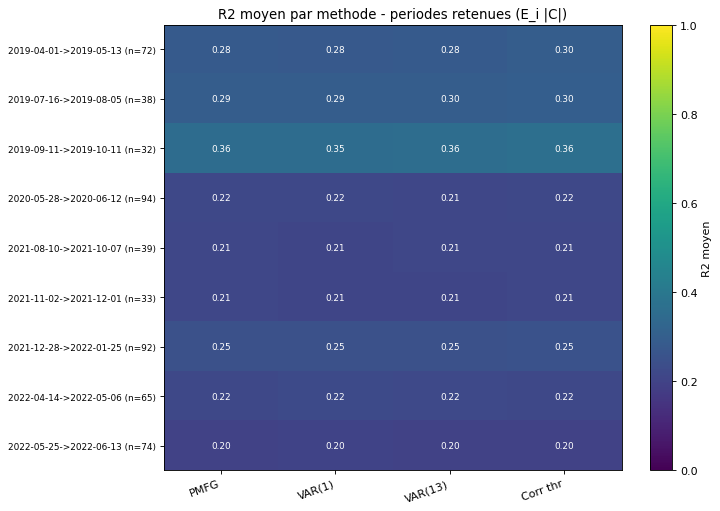

In [71]:
# R2 moyen par periode (|C|) + selection + heatmap + tableau retenu
def _compute_period_data_abs():
    return {(pa, pb): fits_for_abs(pa, pb) for (pa, pb) in intervals_chrono}

_sig_abs = make_sig(data, crisis_map, E_daily_all, intervals_chrono, A_sis,
                    B_fit, R_fit, T_long, tol_eq, SMOOTH2, MIN_LEN, MIN_GAIN, SIS_MODELS, N)
period_data_abs = disk_cache('period_data_abs', _sig_abs, _compute_period_data_abs)

rows_abs = []
mean_r2_abs = np.full((len(intervals_chrono), len(SIS_MODELS)), np.nan)
for pi, (pa, pb) in enumerate(intervals_chrono):
    cache, fits = period_data_abs[(pa, pb)]
    for j, m in enumerate(SIS_MODELS):
        r2s = [fits[m][1][gi]['r2'] for gi in fits[m][1]]
        mean_r2_abs[pi, j] = np.mean(r2s) if r2s else np.nan
    rows_abs.append(f'{all_days[pa]}->{all_days[pb]} (n={len(cache)})')
    print(f'[{pi}] {rows_abs[-1]} : ' +
          ', '.join(f'{m} {mean_r2_abs[pi, j]:.2f}' for j, m in enumerate(SIS_MODELS)))

selected_abs = []
for pi, (pa, pb) in enumerate(intervals_chrono):
    n = len(period_data_abs[(pa, pb)][0])
    if n > N_MIN and np.nanmax(mean_r2_abs[pi]) > R2_PERIOD:
        selected_abs.append((pa, pb))
print(f'\n{len(selected_abs)} periode(s) selectionnee(s) |C| (n > {N_MIN}, R2 > {R2_PERIOD}) :')
for (pa, pb) in selected_abs:
    print(f'  {all_days[pa]} -> {all_days[pb]}')

sel_rows = [intervals_chrono.index(p) for p in selected_abs]
r2_sel_abs_df = pd.DataFrame(mean_r2_abs[sel_rows], index=[rows_abs[i] for i in sel_rows],
                             columns=SIS_MODELS)
print(); print(r2_sel_abs_df.round(3).to_string())

if sel_rows:
    sub = mean_r2_abs[sel_rows]
    fig, ax = plt.subplots(figsize=(1.6 * len(SIS_MODELS) + 3, 0.5 * len(sel_rows) + 2))
    im = ax.imshow(sub, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(SIS_MODELS))); ax.set_xticklabels(SIS_MODELS, rotation=20, ha='right')
    ax.set_yticks(range(len(sel_rows))); ax.set_yticklabels([rows_abs[i] for i in sel_rows], fontsize=8)
    for i in range(len(sel_rows)):
        for j in range(len(SIS_MODELS)):
            v = sub[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v < 0.6 else 'black', fontsize=8)
    cb = fig.colorbar(im, ax=ax); cb.set_label('R2 moyen')
    ax.set_title('R2 moyen par methode - periodes retenues (E_i |C|)', fontsize=12)
    plt.tight_layout(); plt.show()

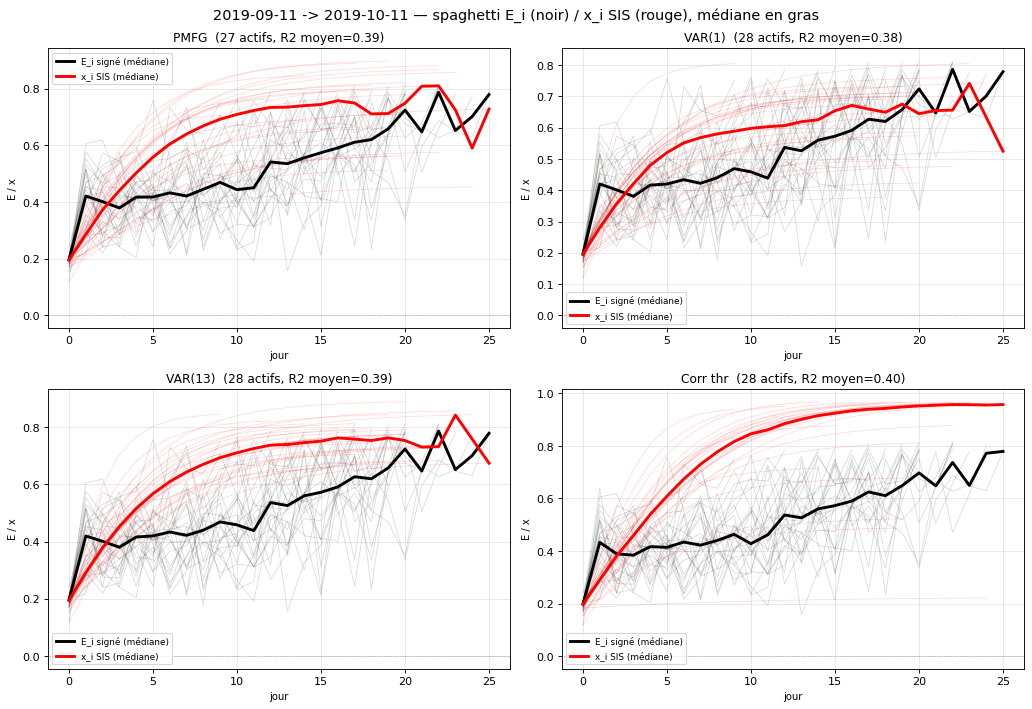

In [72]:
# Spaghettis (|C|)
for (pa, pb) in _disp(selected_abs):
    spaghetti_period(pa, pb, *period_data_abs[(pa, pb)])

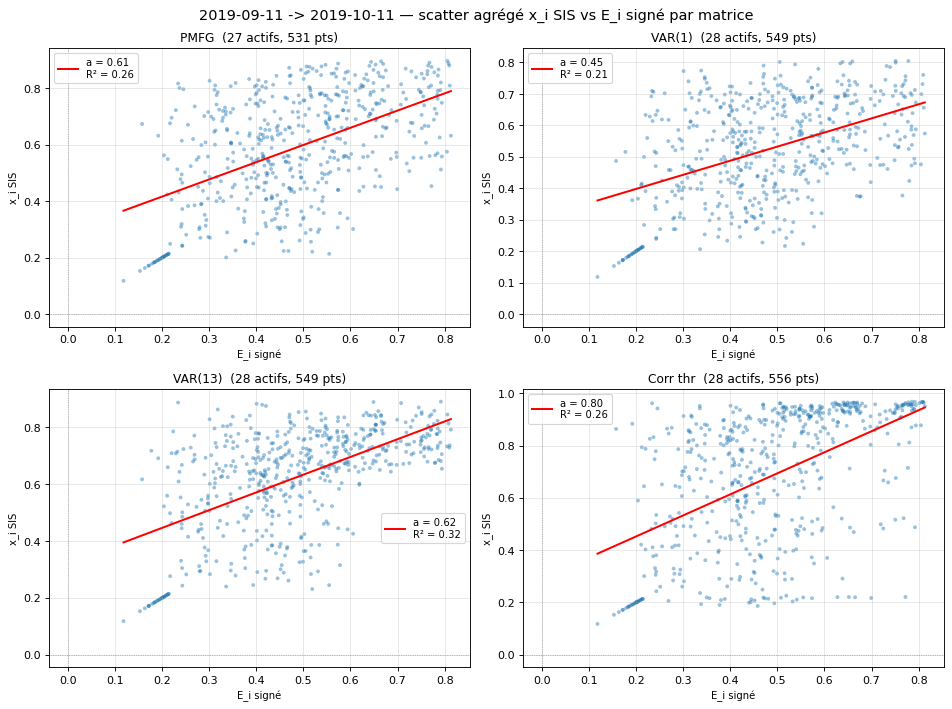

In [73]:
# Scatter agrege par periode et matrice (|C|)
for (pa, pb) in _disp(selected_abs):
    scatter_period(pa, pb, *period_data_abs[(pa, pb)])

(|C|) 129 actifs retenus >= 1 fois sur 9 periodes ; 86 redondants (>= 2) :
AAPL[Information Technology](6), ADI[Information Technology](5), BLK[Financials](5), META[Information Technology](5), SONY[Information Technology](5), AXP[Financials](4), BSX[Healthcare](4), BX[Financials](4), CI[Healthcare](4), CSCO[Information Technology](4), GS[Financials](4), IBM[Information Technology](4), INTC[Information Technology](4), INTU[Information Technology](4), ITW[Consumer Staples](4), LOW[Consumer Discretionary](4), MA[Information Technology](4), MDLZ[Consumer Staples](4), MMC[Financials](4), SBUX[Consumer Discretionary](4), TJX[Consumer Discretionary](4), V[Information Technology](4), ABB[Industrials](3), ACN[Information Technology](3), AMAT[Information Technology](3), AMZN[Consumer Discretionary](3), ASX[Information Technology](3), BAC[Financials](3), BHP[Materials](3), CB[Financials](3), CMCSA[Information Technology](3), CRM[Information Technology](3), ETN[Industrials](3), HD[Consumer Discret

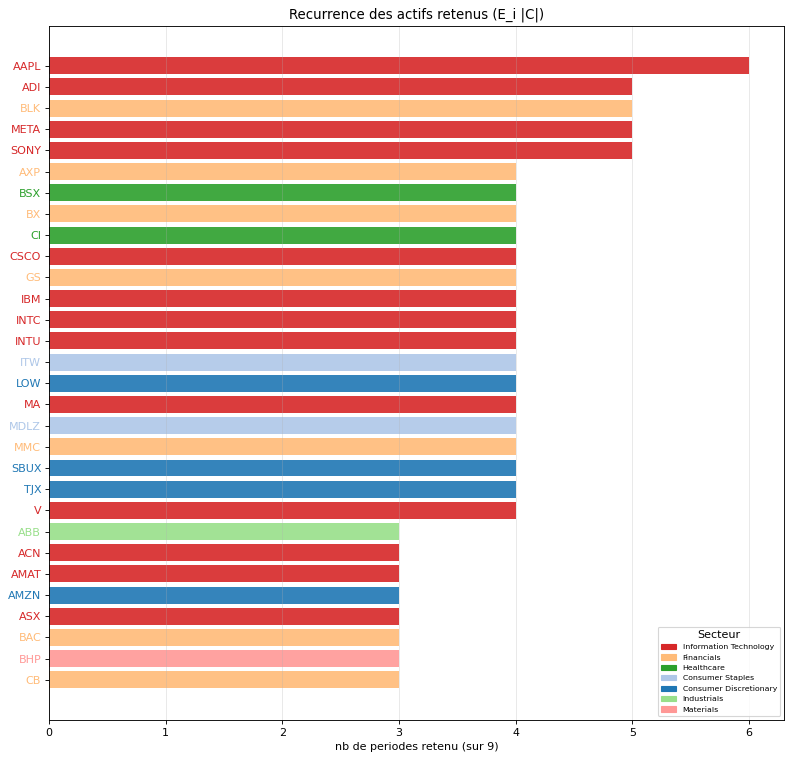

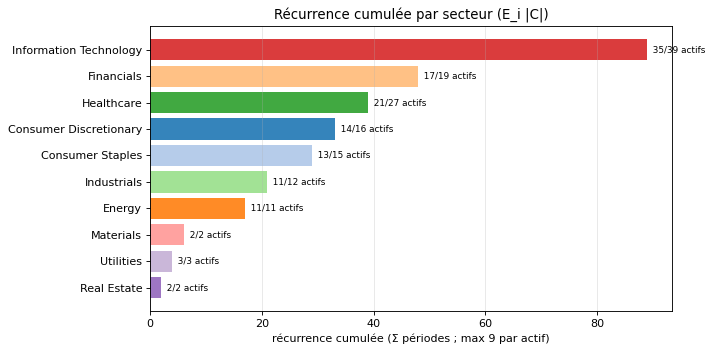

(Counter({'Information Technology': 89,
          'Financials': 48,
          'Healthcare': 39,
          'Consumer Discretionary': 33,
          'Consumer Staples': 29,
          'Industrials': 21,
          'Energy': 17,
          'Materials': 6,
          'Utilities': 4,
          'Real Estate': 2}),
 Counter({'Information Technology': 35,
          'Healthcare': 21,
          'Financials': 17,
          'Consumer Discretionary': 14,
          'Consumer Staples': 13,
          'Energy': 11,
          'Industrials': 11,
          'Utilities': 3,
          'Real Estate': 2,
          'Materials': 2}))

In [74]:
# Recurrence des actifs retenus (|C|) a travers les periodes, par secteur
per_period_assets_abs = {}
cnt_abs = Counter()
for (pa, pb) in selected_abs:
    cache, fits = period_data_abs[(pa, pb)]
    kept = [gi for gi in cache if any(_ok_r2(fits, m, gi) for m in SIS_MODELS)]
    per_period_assets_abs[(pa, pb)] = kept
    for gi in kept:
        cnt_abs[gi] += 1
nP = len(selected_abs)
order = sorted(cnt_abs, key=lambda gi: (-cnt_abs[gi], asset_names[gi]))
redond = [gi for gi in order if cnt_abs[gi] >= 2]
print(f'(|C|) {len(order)} actifs retenus >= 1 fois sur {nP} periodes ; '
      f'{len(redond)} redondants (>= 2) :')
print(', '.join(f'{asset_names[gi]}[{gi_sector(gi)}]({cnt_abs[gi]})' for gi in redond) or '(aucun)')
barh_by_sector(order[:30], cnt_abs,
               'Recurrence des actifs retenus (E_i |C|)',
               f'nb de periodes retenu (sur {nP})')
sector_recurrence_plot(cnt_abs, nP, 'Récurrence cumulée par secteur (E_i |C|)')


Pente a (x_i SIS / E_i |C|) - actifs retenus, periodes selectionnees :
          pente_moy  ecart_type  n_actifs
PMFG          0.505       0.173       276
VAR(1)        0.396       0.144       278
VAR(13)       0.548       0.142       279
Corr thr      0.719       0.241       277


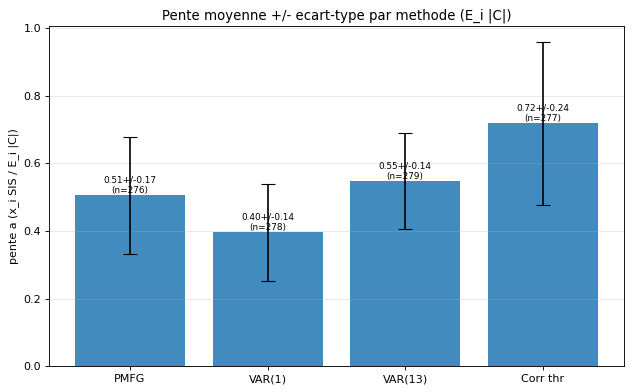

In [75]:
# Pente moyenne +/- ecart-type par methode (|C|, periodes retenues)
slopes_by_m_abs = {m: [] for m in SIS_MODELS}
for (pa, pb) in selected_abs:
    cache, fits = period_data_abs[(pa, pb)]
    for m in SIS_MODELS:
        for gi in fits[m][1]:
            if _ok_r2(fits, m, gi):
                slopes_by_m_abs[m].append(fits[m][1][gi]['slope'])
stats = {m: (np.mean(s), np.std(s), len(s)) for m, s in slopes_by_m_abs.items()}
slope_stats_abs_df = pd.DataFrame(
    {'pente_moy': [stats[m][0] for m in SIS_MODELS],
     'ecart_type': [stats[m][1] for m in SIS_MODELS],
     'n_actifs':  [stats[m][2] for m in SIS_MODELS]},
    index=SIS_MODELS)
print('Pente a (x_i SIS / E_i |C|) - actifs retenus, periodes selectionnees :')
print(slope_stats_abs_df.round(3).to_string())
means = [stats[m][0] for m in SIS_MODELS]; stds = [stats[m][1] for m in SIS_MODELS]
fig, ax = plt.subplots(figsize=(8, 5)); x = np.arange(len(SIS_MODELS))
ax.bar(x, means, yerr=stds, capsize=6, color='#1f77b4', alpha=0.85)
for i, m in enumerate(SIS_MODELS):
    ax.text(i, means[i], f'{means[i]:.2f}+/-{stds[i]:.2f}\n(n={stats[m][2]})',
            ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='gray', lw=0.6, ls=':')
ax.set_xticks(x); ax.set_xticklabels(SIS_MODELS)
ax.set_ylabel('pente a (x_i SIS / E_i |C|)')
ax.set_title('Pente moyenne +/- ecart-type par methode (E_i |C|)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

Periodes retenues (|C|) - duree (jours) et actifs retenus par secteur :
     debut        fin  duree_j  n_actifs  Consumer Discretionary  Consumer Staples  Energy  Financials  Healthcare  Industrials  Information Technology  Materials  Real Estate  Utilities
2019-04-01 2019-05-13       42        45                       4                 3       3           7           8            5                      14          0            1          0
2019-07-16 2019-08-05       20        23                       5                 2       0           5           2            1                       8          0            0          0
2019-09-11 2019-10-11       30        29                       1                 2       3           7           5            2                       9          0            0          0
2020-05-28 2020-06-12       15        41                       5                 5       2           3           5            4                      12          1            1     

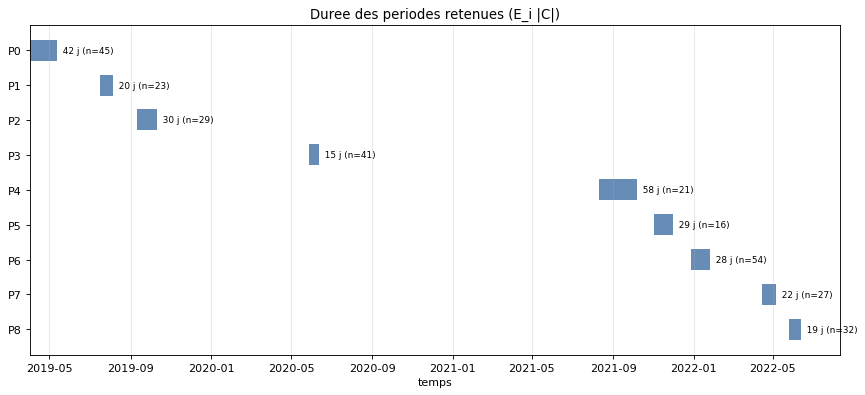

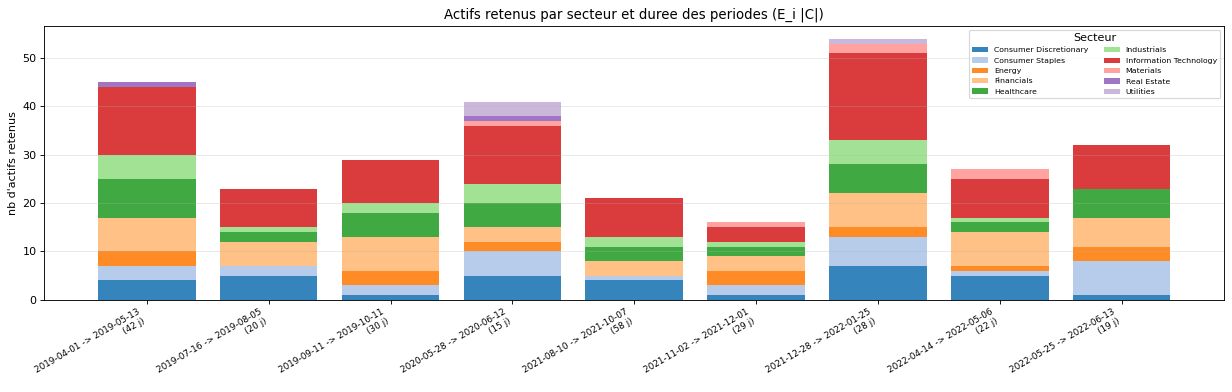

In [76]:
# Duree des periodes retenues + actifs retenus par secteur (|C|)
import matplotlib.dates as mdates

rows = []
for (pa, pb) in selected_abs:
    d0, d1 = all_days[pa], all_days[pb]
    kept = per_period_assets_abs[(pa, pb)]
    sec_cnt = _Counter(gi_sector(gi) for gi in kept)
    rows.append(dict(debut=d0, fin=d1, duree_j=(d1 - d0).days, n_actifs=len(kept),
                     **{s: sec_cnt.get(s, 0) for s in sector_list}))
dur_df = pd.DataFrame(rows)
present = [s for s in sector_list if dur_df[s].sum() > 0]
print('Periodes retenues (|C|) - duree (jours) et actifs retenus par secteur :')
print(dur_df[['debut', 'fin', 'duree_j', 'n_actifs'] + present].to_string(index=False))
print(f"\nDuree : moyenne {dur_df.duree_j.mean():.0f} j, "
      f"min {dur_df.duree_j.min()} j, max {dur_df.duree_j.max()} j, "
      f"cumul {dur_df.duree_j.sum()} j")

# (1) Frise : chaque periode positionnee dans le temps, longueur de la barre = duree
fig, ax = plt.subplots(figsize=(11, max(2.5, 0.45 * len(dur_df) + 1)))
for i, r in enumerate(dur_df.itertuples()):
    x0 = mdates.date2num(r.debut)
    ax.barh(i, mdates.date2num(r.fin) - x0, left=x0, height=0.6, color='#4c78a8', alpha=0.85)
    ax.text(mdates.date2num(r.fin), i, f'  {r.duree_j} j (n={r.n_actifs})', va='center', fontsize=8)
ax.set_yticks(range(len(dur_df))); ax.set_yticklabels([f'P{i}' for i in range(len(dur_df))])
ax.invert_yaxis(); ax.xaxis_date()
ax.set_xlabel('temps'); ax.set_title('Duree des periodes retenues (E_i |C|)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

# (2) Barres empilees : actifs retenus par secteur, une barre par periode
x = np.arange(len(dur_df)); bottom = np.zeros(len(dur_df))
fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(dur_df) + 2), 5))
for s in present:
    v = dur_df[s].values
    ax.bar(x, v, bottom=bottom, color=sector_color[s], label=s, alpha=0.9)
    bottom += v
ax.set_xticks(x)
ax.set_xticklabels([f'{r.debut} -> {r.fin}\n({r.duree_j} j)' for r in dur_df.itertuples()],
                   rotation=30, ha='right', fontsize=8)
ax.set_ylabel("nb d'actifs retenus")
ax.set_title('Actifs retenus par secteur et duree des periodes (E_i |C|)')
ax.legend(fontsize=7, title='Secteur', ncol=2)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## Nombre de jours de crise par actif et par période

Pour chaque actif et chaque période retenue `(pa, pb)`, on compte le **nombre de jours en crise** : `crisis_map[gi, pa:pb+1].sum()`. On regarde si ce nombre reste stable d'une période à l'autre, et s'il dépend du secteur.

146/146 actifs en crise sur >= 1 des 9 periodes

Jours de crise par actif et par periode (top 15 par total) :
actif                secteur  P0  P1  P2  P3  P4  P5  P6  P7  P8  total
 PYPL            Industrials  25  15  23  12  42  21  20  16  13    187
  AMD Information Technology  30  15  20  12  42  18  20  16  13    186
 HSBC             Financials  30  15  18  12  35  21  19  16  13    179
  HON       Consumer Staples  29  14  23  12  37  15  20  16  13    179
  ZTS             Healthcare  30  15  15  12  37  21  20  16  13    179
  NOW Information Technology  25  15  20  12  41  21  20  11  13    178
   CB             Financials  30  15  19  12  38  19  16  15  13    177
  NVS             Healthcare  24  15  22  12  42  14  20  15  13    177
  BHP              Materials  30   6  23  11  42  18  20  16  10    176
  AZN             Healthcare  30  15  21  12  31  21  19  13  12    174
 GOOG Information Technology  26  15  18  12  39  21  14  16  13    174
 NVDA Information Technolo

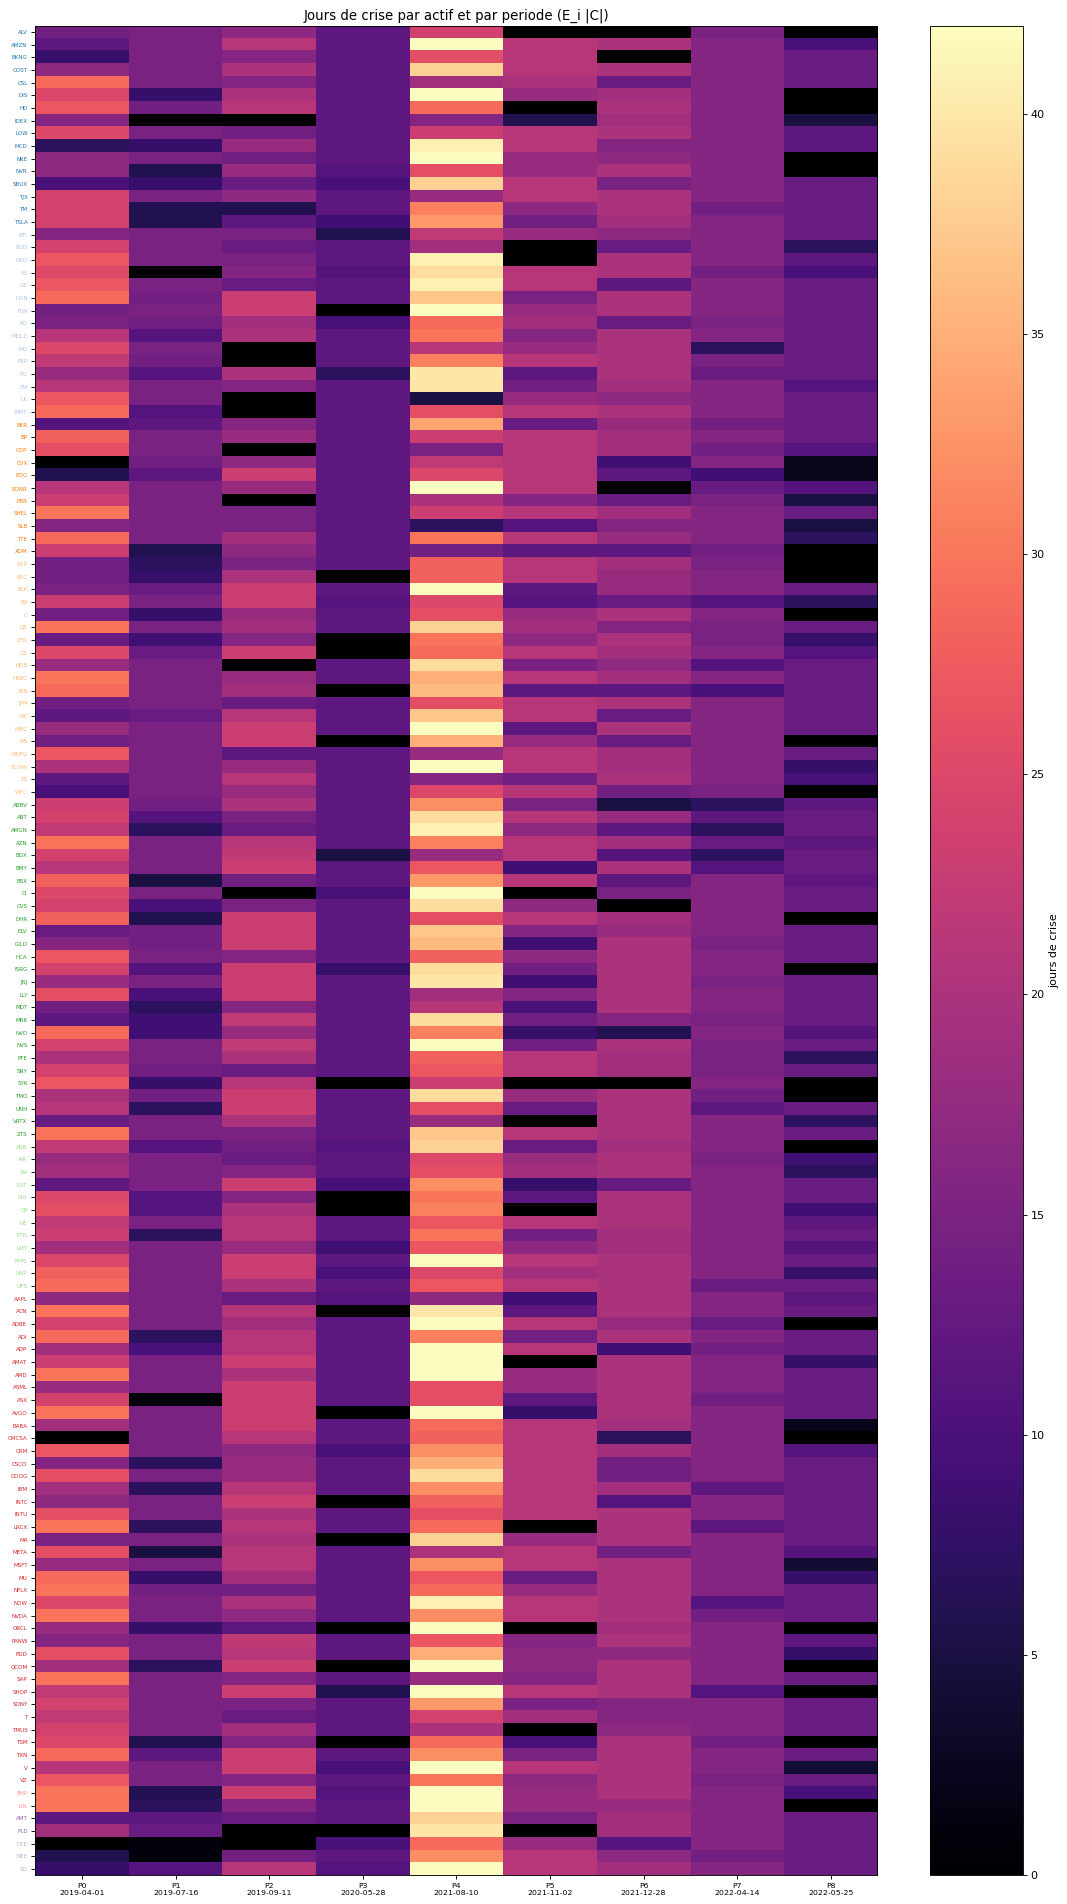

In [77]:
# Nombre de jours de crise par actif et par periode (|C|)
periods = selected_abs
sec_of  = np.array([gi_sector(gi) for gi in range(N)])
CD = np.array([[int(crisis_map[gi, pa:pb + 1].sum()) for (pa, pb) in periods]
               for gi in range(N)])                     # (N, P) jours de crise par periode
active = CD.sum(axis=1) > 0
print(f'{active.sum()}/{N} actifs en crise sur >= 1 des {len(periods)} periodes')

# tableau par actif (jours de crise periode par periode)
cd_df = pd.DataFrame(CD, columns=[f'P{i}' for i in range(len(periods))])
cd_df.insert(0, 'secteur', sec_of); cd_df.insert(0, 'actif', asset_names)
cd_df['total'] = CD.sum(axis=1)
print('\nJours de crise par actif et par periode (top 15 par total) :')
print(cd_df[active].sort_values('total', ascending=False).head(15).to_string(index=False))

# --- reste-t-il constant d'une periode a l'autre ? ---
print('\n--- Stabilite entre periodes (jours de crise bruts) ---')
print(f'Ecart-type intra-actif median (sur les periodes) = '
      f'{np.median(CD[active].std(axis=1)):.1f} j   (0 = constant)')
print('Jours de crise par periode (moyenne +/- ecart-type sur actifs en crise) :')
for i, (pa, pb) in enumerate(periods):
    col = CD[active, i]
    print(f'  P{i} {all_days[pa]} -> {all_days[pb]} ({pb - pa + 1} j) : '
          f'{col.mean():.1f} +/- {col.std():.1f} j   (max {col.max()})')

# heatmap jours de crise (actifs en crise, tries par secteur)
gis = sorted(np.where(active)[0], key=lambda gi: (gi_sector(gi), asset_names[gi]))
Hc = CD[gis]
fig, ax = plt.subplots(figsize=(1.2 * len(periods) + 3, 0.15 * len(gis) + 2))
im = ax.imshow(Hc, aspect='auto', cmap='magma', vmin=0, vmax=Hc.max())
ax.set_xticks(range(len(periods)))
ax.set_xticklabels([f'P{i}\n{all_days[pa]}' for i, (pa, pb) in enumerate(periods)], fontsize=7)
ax.set_yticks(range(len(gis))); ax.set_yticklabels([asset_names[gi] for gi in gis], fontsize=5)
for tick, gi in zip(ax.get_yticklabels(), gis):
    tick.set_color(gi_color(gi))
cb = fig.colorbar(im, ax=ax); cb.set_label('jours de crise')
ax.set_title('Jours de crise par actif et par periode (E_i |C|)')
plt.tight_layout(); plt.show()


Jours de crise moyens par actif (secteur x periode) :
                          P0    P1    P2    P3    P4    P5    P6    P7    P8   moy
Materials               30.0   6.5  19.5  11.5  42.0  18.0  19.0  16.0   5.0  18.6
Information Technology  23.1  12.5  19.6   9.6  32.4  15.8  18.2  15.2   9.7  17.3
Industrials             22.3  13.3  19.0   9.3  30.0  15.2  19.2  15.7  10.1  17.1
Healthcare              22.5  11.9  18.9  11.1  31.8  14.2  15.9  14.1  10.4  16.7
Consumer Staples        22.7  13.0  12.9  10.3  30.9  15.5  18.1  14.9  12.2  16.7
Financials              18.5  13.2  18.1   8.8  31.4  17.7  17.3  14.9   8.5  16.5
Consumer Discretionary  18.5  11.0  15.2  11.6  30.5  16.1  16.1  15.8   8.1  15.9
Energy                  19.4  13.5  14.4  12.0  23.2  18.1  14.1  14.5   7.5  15.2
Real Estate             15.5  12.5   6.5   6.0  39.0   7.5  19.0  16.0  13.0  15.0
Utilities                4.7   4.3  11.7  11.0  34.3  20.0  15.7  15.3  13.0  14.4

Kruskal-Wallis (jours de crise ~

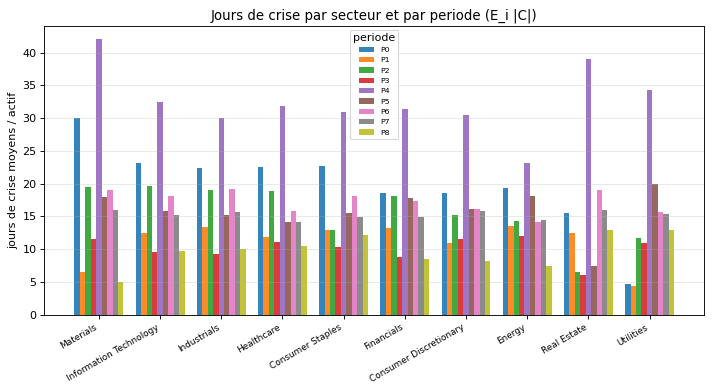

In [78]:
# Jours de crise par secteur et par periode (|C|)
from scipy.stats import kruskal

SM = np.zeros((len(sector_list), len(periods)))          # jours moyens / actif, secteur x periode
for r, s in enumerate(sector_list):
    SM[r] = CD[sec_of == s].mean(axis=0)
sec_df = pd.DataFrame(SM, index=sector_list, columns=[f'P{i}' for i in range(len(periods))])
sec_df['moy'] = sec_df.mean(axis=1)
sec_df = sec_df.sort_values('moy', ascending=False)
print('Jours de crise moyens par actif (secteur x periode) :')
print(sec_df.round(1).to_string())

print('\nKruskal-Wallis (jours de crise ~ secteur), periode par periode :')
for i, (pa, pb) in enumerate(periods):
    groups = [CD[sec_of == s, i] for s in sector_list if (sec_of == s).any()]
    Hs, pv = kruskal(*groups)
    print(f'  P{i} {all_days[pa]} : H={Hs:5.1f}, p={pv:.1e}' + ('  *' if pv < 0.05 else ''))

# barres groupees : jours moyens par secteur et par periode
order = sec_df.index.tolist(); x = np.arange(len(order)); w = 0.8 / len(periods)
fig, ax = plt.subplots(figsize=(max(9, 0.7 * len(order) + 2), 5))
for i in range(len(periods)):
    ax.bar(x + i * w, sec_df[f'P{i}'].values, width=w, label=f'P{i}', alpha=0.9)
ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(order, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('jours de crise moyens / actif'); ax.legend(fontsize=7, title='periode')
ax.set_title('Jours de crise par secteur et par periode (E_i |C|)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## Effet de la valeur absolue sur A : réseaux signés vs |A|

On reprend les quatre réseaux (`PMFG`, `VAR(1)`, `VAR(13)`, `Corr thr`) mais à **poids signés** (on retire le `np.abs`), donc avec `|A_signé| = A_sis` actuel. On rejoue le SIS sur la période affichée et on compare la régression agrégée `x_i` SIS vs `E_i` signé : **bleu = |A|** (actuel), **rouge = A signé**.

2019-09-11 -> 2019-10-11 : 32 actifs
[cache] OK  signedA_2019-09-11  (rechargé depuis .cache/periods_analysis/signedA_2019-09-11.7de004824809401f.pkl)


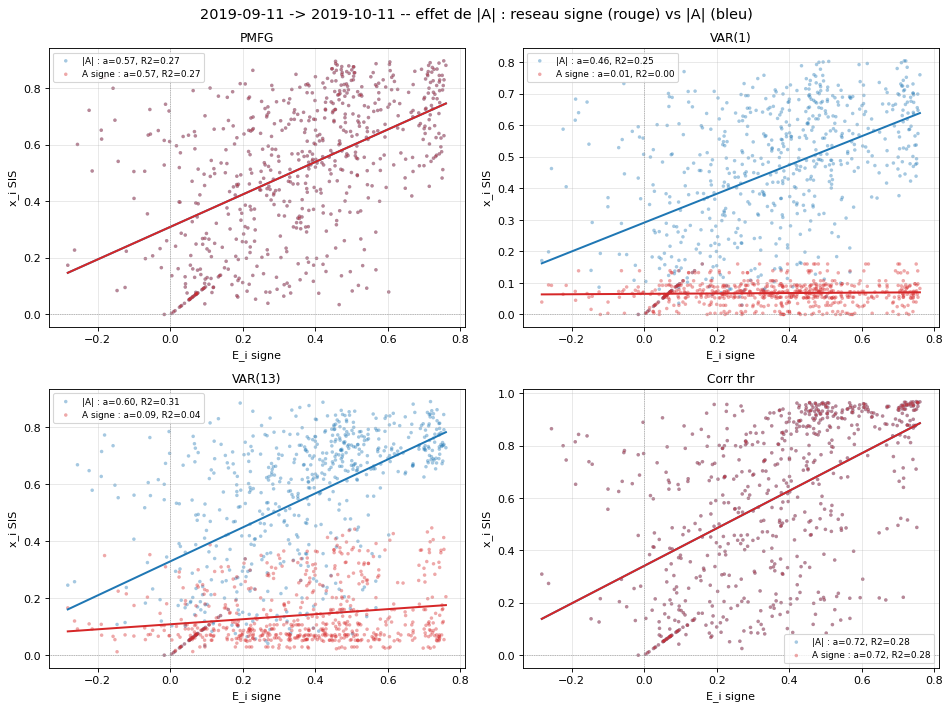

 matrice  a_absA  R2_absA  a_signe  R2_signe
    PMFG   0.574    0.273    0.574     0.273
  VAR(1)   0.457    0.250    0.006     0.002
 VAR(13)   0.596    0.311    0.088     0.037
Corr thr   0.716    0.284    0.716     0.284


In [79]:
# ── Effet de la VALEUR ABSOLUE sur A : reseaux SIGNES vs |A| (periode affichee)
# Memes reseaux que A_sis mais a poids SIGNES (on retire le np.abs) ; on rejoue le
# SIS et on compare la regression agregee x_i SIS vs E_i signe (pente a, R2).
C_signed = np.nan_to_num(np.corrcoef(data.values.T), nan=0.0); np.fill_diagonal(C_signed, 0)
thr80 = np.quantile(C_full[mask_off], CORR_THRESHOLD)        # meme seuil que 'Corr thr'

def _diag0(A):
    A = np.array(A, dtype=float); np.fill_diagonal(A, 0); return A

A_signed = {
    'PMFG':     np.where(A_pmfg != 0, C_signed, 0.0),        # structure planaire, poids signes
    'VAR(1)':   _diag0(fit_var(data.values, 1)),             # fit_var SANS np.abs
    'VAR(13)':  _diag0(fit_var(data.values, 13)),
    'Corr thr': _diag0(np.where(np.abs(C_signed) >= thr80, C_signed, 0.0)),
}

for (pa, pb) in _disp(selected):
    cache, fits = period_data[(pa, pb)]; lab = f'{all_days[pa]} -> {all_days[pb]}'
    print(f'{lab} : {len(cache)} actifs')
    sig = make_sig(cache, A_signed, B_fit, R_fit, T_long, tol_eq)
    sgn = disk_cache(f'signedA_{all_days[pa]}', sig,
                     lambda c=cache: {m: {gi: integrate(c, gi, A_signed[m]) for gi in c}
                                      for m in SIS_MODELS})
    rows = []
    fig, axes = plt.subplots(2, 2, figsize=(12, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        Es, Xa, Xs = [], [], []
        for gi in cache:
            E_i, xa = fits[m][0][gi]; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            Es.append(E_i[ok]); Xa.append(xa[ok]); Xs.append(sgn[m][gi][ok])
        Es = np.concatenate(Es); Xa = np.concatenate(Xa); Xs = np.concatenate(Xs)
        fA = linregress(Es, Xa); fS = linregress(Es, Xs)
        rows.append((m, fA.slope, fA.rvalue ** 2, fS.slope, fS.rvalue ** 2))
        ax.scatter(Es, Xa, s=10, color='#1f77b4', alpha=0.4, edgecolors='none',
                   label=f'|A| : a={fA.slope:.2f}, R2={fA.rvalue**2:.2f}')
        ax.scatter(Es, Xs, s=10, color='#d62728', alpha=0.4, edgecolors='none',
                   label=f'A signe : a={fS.slope:.2f}, R2={fS.rvalue**2:.2f}')
        xs = np.linspace(Es.min(), Es.max(), 50)
        ax.plot(xs, fA.slope * xs + fA.intercept, color='#1f77b4', lw=1.8)
        ax.plot(xs, fS.slope * xs + fS.intercept, color='#d62728', lw=1.8)
        ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(m, fontsize=11); ax.set_xlabel('E_i signe'); ax.set_ylabel('x_i SIS')
        ax.legend(fontsize=8, loc='best'); ax.grid(alpha=0.3)
    plt.suptitle(f'{lab} -- effet de |A| : reseau signe (rouge) vs |A| (bleu)', fontsize=13)
    plt.tight_layout(); plt.show()
    comp = pd.DataFrame(rows, columns=['matrice', 'a_absA', 'R2_absA', 'a_signe', 'R2_signe'])
    print(comp.round(3).to_string(index=False))


## A sans valeur absolue (réseaux signés) : E_i signé vs E_i en valeur absolue

Même matrice **A signée** (`|A_signé| = A_sis`) dans les deux cas. Seule la cible empirique change : d'abord les 4 plots (un par matrice) avec **E_i signé** (cache signé, `x0` signé), puis avec **E_i en valeur absolue** (cache |C|, `x0` absolu). Régression agrégée `x_i` SIS vs `E_i`.

[cache] OK  signedA_2019-09-11  (rechargé depuis .cache/periods_analysis/signedA_2019-09-11.7de004824809401f.pkl)
[cache] OK  signedAabs_2019-09-11  (rechargé depuis .cache/periods_analysis/signedAabs_2019-09-11.352262ad3ec4b7ab.pkl)
2019-09-11 -> 2019-10-11 : A signe . E_i SIGNE (32 actifs)


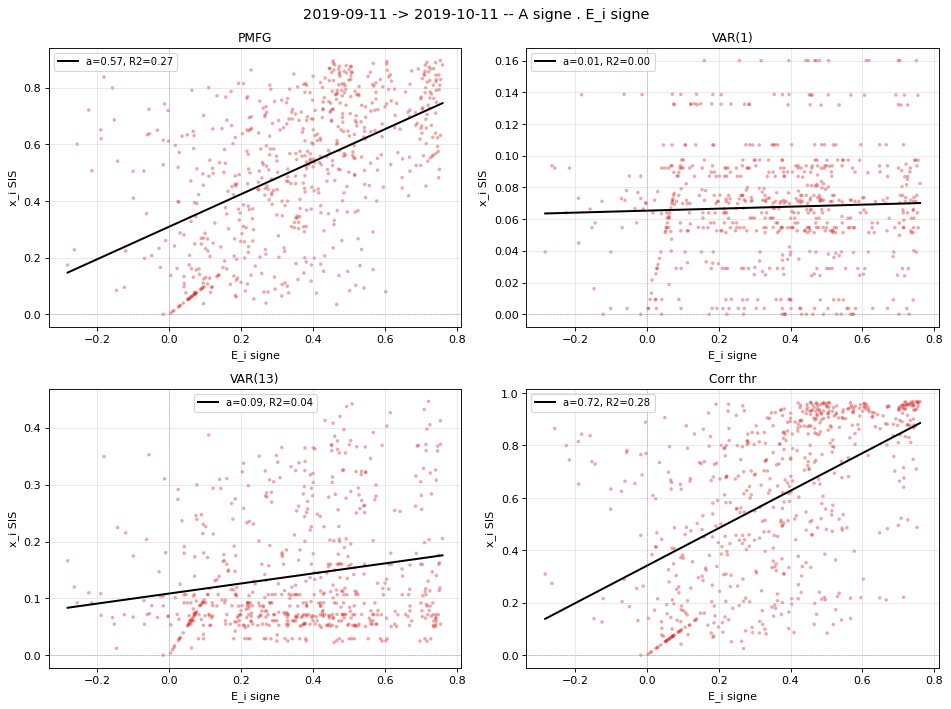

 matrice     a    R2
    PMFG 0.574 0.273
  VAR(1) 0.006 0.002
 VAR(13) 0.088 0.037
Corr thr 0.716 0.284

2019-09-11 -> 2019-10-11 : A signe . E_i VALEUR ABSOLUE (32 actifs)


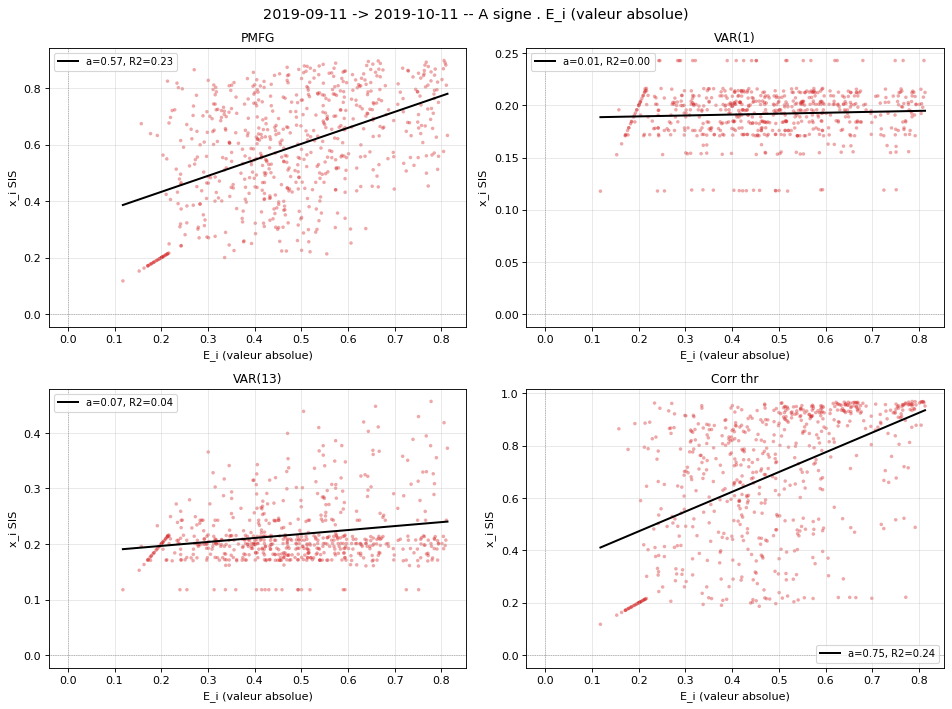

 matrice     a    R2
    PMFG 0.565 0.228
  VAR(1) 0.009 0.004
 VAR(13) 0.071 0.044
Corr thr 0.753 0.237


In [80]:
# ── A SANS valeur absolue : x_i SIS vs E_i signe, PUIS vs E_i |valeur absolue|
# Reseaux signes (memes magnitudes que A_sis). Set 1 : cache signe (E_i, x0 signes).
# Set 2 : cache |C| (E_i, x0 absolus). 4 plots (un par matrice) dans chaque cas.
C_signed = np.nan_to_num(np.corrcoef(data.values.T), nan=0.0); np.fill_diagonal(C_signed, 0)
_thr = np.quantile(C_full[mask_off], CORR_THRESHOLD)

def _diag0(A):
    A = np.array(A, dtype=float); np.fill_diagonal(A, 0); return A

A_signed = {
    'PMFG':     np.where(A_pmfg != 0, C_signed, 0.0),
    'VAR(1)':   _diag0(fit_var(data.values, 1)),
    'VAR(13)':  _diag0(fit_var(data.values, 13)),
    'Corr thr': _diag0(np.where(np.abs(C_signed) >= _thr, C_signed, 0.0)),
}

def scatter_grid(cache, traj, lab, elabel):
    """Grille 2x2 (1 plot/matrice) : x_i SIS (A signe) vs cible empirique 'elabel'."""
    rows = []
    fig, axes = plt.subplots(2, 2, figsize=(12, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        Es, Xs = [], []
        for gi in cache:
            E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            Es.append(E_i[ok]); Xs.append(traj[m][gi][ok])
        Es = np.concatenate(Es); Xs = np.concatenate(Xs)
        f = linregress(Es, Xs); rows.append((m, f.slope, f.rvalue ** 2))
        ax.scatter(Es, Xs, s=10, color='#d62728', alpha=0.4, edgecolors='none')
        xs = np.linspace(Es.min(), Es.max(), 50)
        ax.plot(xs, f.slope * xs + f.intercept, color='black', lw=1.8,
                label=f'a={f.slope:.2f}, R2={f.rvalue**2:.2f}')
        ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(m, fontsize=11); ax.set_xlabel(elabel); ax.set_ylabel('x_i SIS')
        ax.legend(fontsize=9, loc='best'); ax.grid(alpha=0.3)
    plt.suptitle(f'{lab} -- A signe . {elabel}', fontsize=13)
    plt.tight_layout(); plt.show()
    return pd.DataFrame(rows, columns=['matrice', 'a', 'R2'])

for (pa, pb) in _disp(selected):
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    cache_s = period_data[(pa, pb)][0]          # E_i / x0 SIGNES
    cache_a = period_data_abs[(pa, pb)][0]      # E_i / x0 ABSOLUS
    sig_s = make_sig(cache_s, A_signed, B_fit, R_fit, T_long, tol_eq)
    sig_a = make_sig(cache_a, A_signed, B_fit, R_fit, T_long, tol_eq)
    traj_s = disk_cache(f'signedA_{all_days[pa]}', sig_s,
        lambda c=cache_s: {m: {gi: integrate(c, gi, A_signed[m]) for gi in c} for m in SIS_MODELS})
    traj_a = disk_cache(f'signedAabs_{all_days[pa]}', sig_a,
        lambda c=cache_a: {m: {gi: integrate(c, gi, A_signed[m]) for gi in c} for m in SIS_MODELS})

    print(f'{lab} : A signe . E_i SIGNE ({len(cache_s)} actifs)')
    print(scatter_grid(cache_s, traj_s, lab, 'E_i signe').round(3).to_string(index=False))
    print(f'\n{lab} : A signe . E_i VALEUR ABSOLUE ({len(cache_a)} actifs)')
    print(scatter_grid(cache_a, traj_a, lab, 'E_i (valeur absolue)').round(3).to_string(index=False))


### Pendant AVEC valeur absolue sur A (|A| = A_sis)

Même chose mais avec **|A|** (les matrices `A_sis` actuelles) au lieu de A signé. Les trajectoires |A| existent déjà : `period_data` (vs E_i signé) et `period_data_abs` (vs E_i absolu). À comparer à la cellule signée juste au-dessus pour compléter le 2×2 des cas.

2019-09-11 -> 2019-10-11 : |A| . E_i SIGNE (32 actifs)


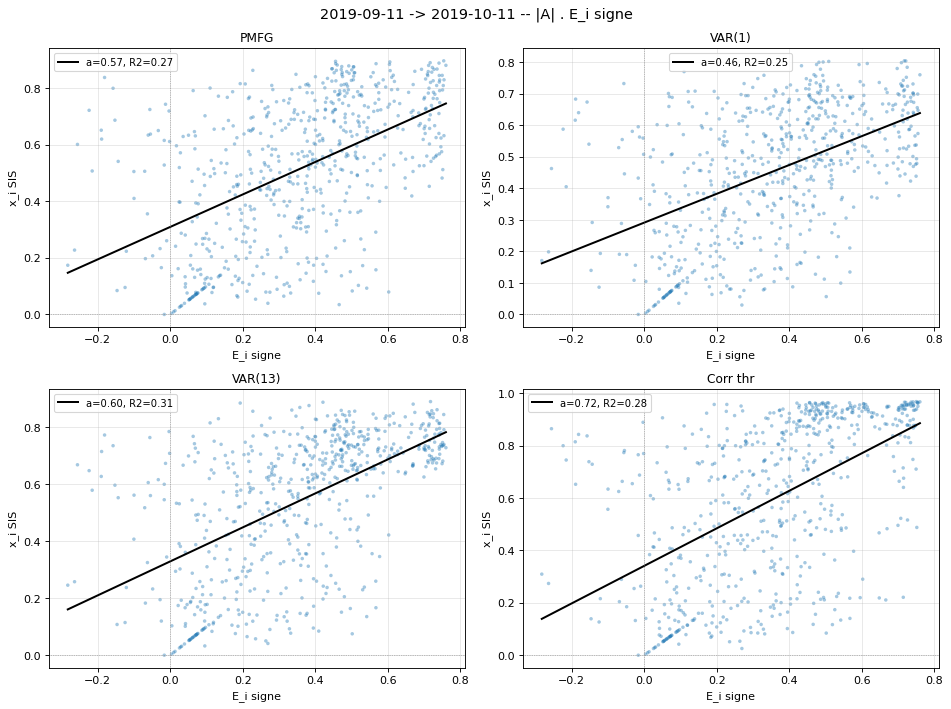

 matrice     a    R2
    PMFG 0.574 0.273
  VAR(1) 0.457 0.250
 VAR(13) 0.596 0.311
Corr thr 0.716 0.284

2019-09-11 -> 2019-10-11 : |A| . E_i VALEUR ABSOLUE (32 actifs)


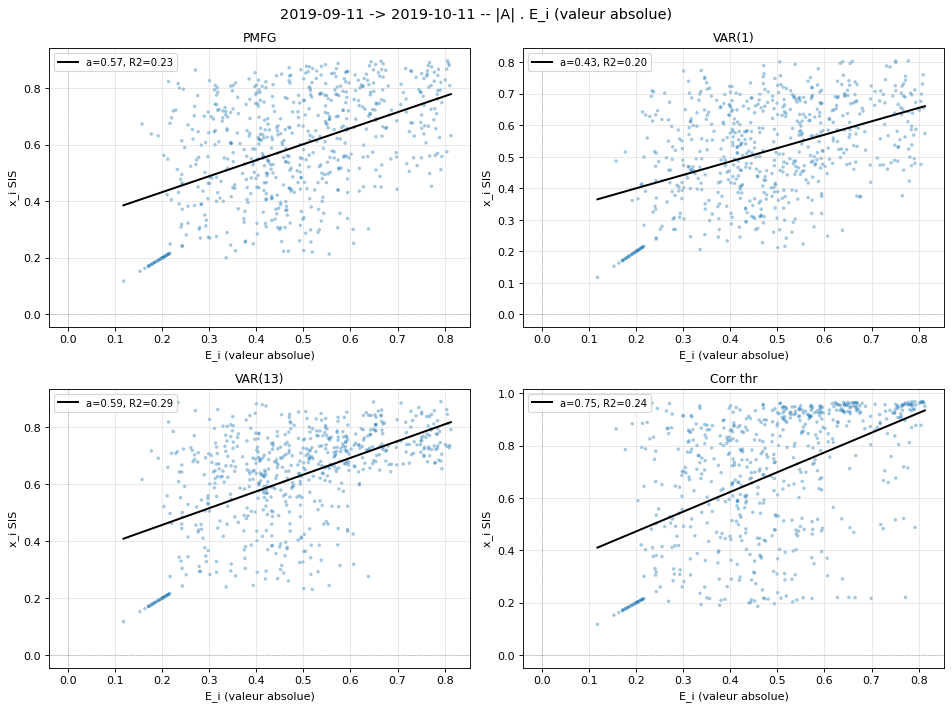

 matrice     a    R2
    PMFG 0.565 0.228
  VAR(1) 0.425 0.196
 VAR(13) 0.588 0.289
Corr thr 0.753 0.237


In [81]:
# ── AVEC valeur absolue sur A (|A| = A_sis) : x_i SIS vs E_i signe, PUIS vs |E_i|
# Pendant exact de la cellule signee ci-dessus, avec |A|. Les trajectoires |A|
# sont deja calculees : period_data (E_i signe) et period_data_abs (E_i absolu).

def scatter_grid_A(cache, traj, lab, atag, elabel):
    """Grille 2x2 (1 plot/matrice) : x_i SIS vs cible empirique 'elabel', label A 'atag'."""
    rows = []
    fig, axes = plt.subplots(2, 2, figsize=(12, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        Es, Xs = [], []
        for gi in cache:
            E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            Es.append(E_i[ok]); Xs.append(traj[m][gi][ok])
        Es = np.concatenate(Es); Xs = np.concatenate(Xs)
        f = linregress(Es, Xs); rows.append((m, f.slope, f.rvalue ** 2))
        ax.scatter(Es, Xs, s=10, color='#1f77b4', alpha=0.4, edgecolors='none')
        xs = np.linspace(Es.min(), Es.max(), 50)
        ax.plot(xs, f.slope * xs + f.intercept, color='black', lw=1.8,
                label=f'a={f.slope:.2f}, R2={f.rvalue**2:.2f}')
        ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(m, fontsize=11); ax.set_xlabel(elabel); ax.set_ylabel('x_i SIS')
        ax.legend(fontsize=9, loc='best'); ax.grid(alpha=0.3)
    plt.suptitle(f'{lab} -- {atag} . {elabel}', fontsize=13)
    plt.tight_layout(); plt.show()
    return pd.DataFrame(rows, columns=['matrice', 'a', 'R2'])

for (pa, pb) in _disp(selected):
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    cache_s, fits_s = period_data[(pa, pb)]          # |A|, E_i signe
    cache_a, fits_a = period_data_abs[(pa, pb)]      # |A|, E_i absolu
    traj_s = {m: {gi: fits_s[m][0][gi][1] for gi in cache_s} for m in SIS_MODELS}
    traj_a = {m: {gi: fits_a[m][0][gi][1] for gi in cache_a} for m in SIS_MODELS}
    print(f'{lab} : |A| . E_i SIGNE ({len(cache_s)} actifs)')
    print(scatter_grid_A(cache_s, traj_s, lab, '|A|', 'E_i signe').round(3).to_string(index=False))
    print(f'\n{lab} : |A| . E_i VALEUR ABSOLUE ({len(cache_a)} actifs)')
    print(scatter_grid_A(cache_a, traj_a, lab, '|A|', 'E_i (valeur absolue)').round(3).to_string(index=False))


### A sans valeur absolue : courbes en fonction du temps

Mêmes trajectoires (A signée) mais vues **en fonction du temps** : par matrice (2×2), `E_i(t)` (noir) et `x_i(t)` SIS (rouge), moyenne en gras + spaghetti léger en fond. D'abord cadrage **E_i signé**, puis **E_i en valeur absolue**.

[cache] OK  signedA_q70_2019-09-11  (rechargé depuis .cache/periods_analysis/signedA_q70_2019-09-11.f575033d2965b8e5.pkl)
[cache] OK  signedAabs_q70_2019-09-11  (rechargé depuis .cache/periods_analysis/signedAabs_q70_2019-09-11.d78c4a3173fcaef1.pkl)


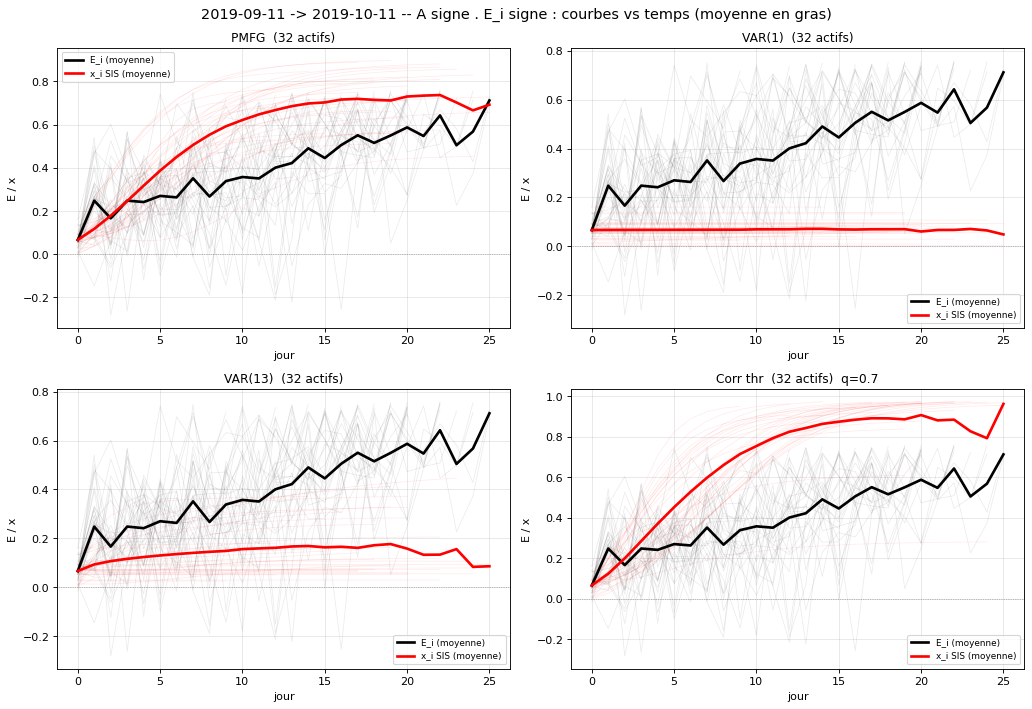

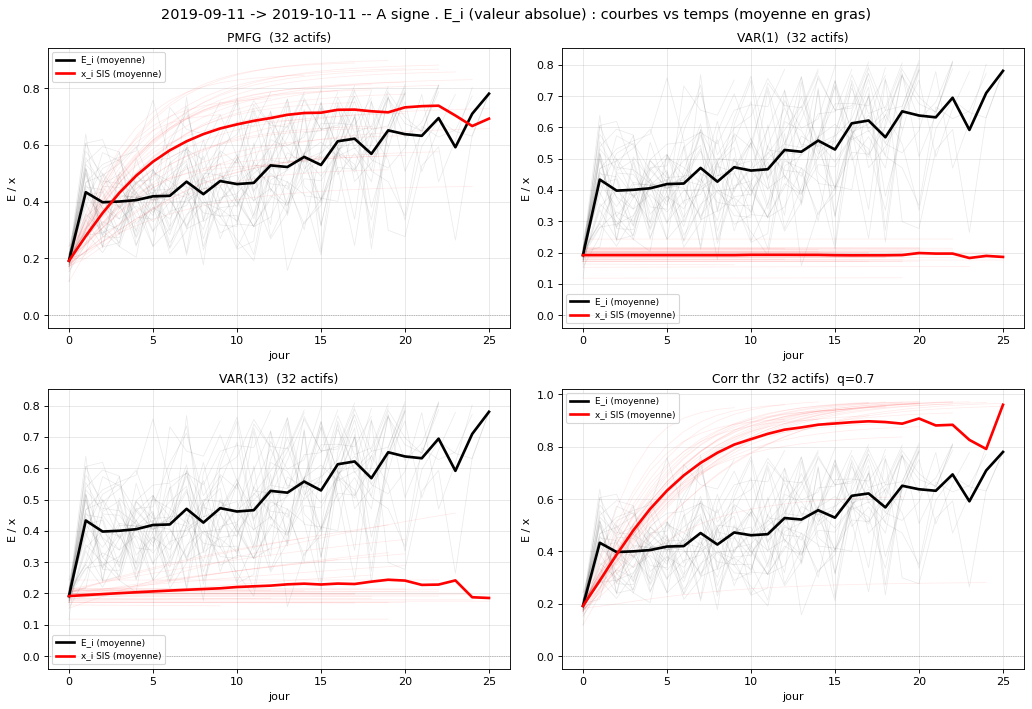

In [82]:
# ── A SANS valeur absolue : courbes x_i SIS / E_i en fonction du TEMPS ───────
# Memes trajectoires signees que ci-dessus, tracees vs jour (moyenne en gras +
# spaghetti leger). Set 1 : cache signe ; Set 2 : cache |C|. Reutilise A_signed.
C_signed = np.nan_to_num(np.corrcoef(data.values.T), nan=0.0); np.fill_diagonal(C_signed, 0)
CORR_THR_HERE = 0.7   # seuil 'Corr thr' propre a cette cellule (au lieu de 0.80)
_thr = np.quantile(C_full[mask_off], CORR_THR_HERE)
def _diag0(A):
    A = np.array(A, dtype=float); np.fill_diagonal(A, 0); return A
A_signed = {
    'PMFG':     np.where(A_pmfg != 0, C_signed, 0.0),
    'VAR(1)':   _diag0(fit_var(data.values, 1)),
    'VAR(13)':  _diag0(fit_var(data.values, 13)),
    'Corr thr': _diag0(np.where(np.abs(C_signed) >= _thr, C_signed, 0.0)),
}

def time_grid(cache, traj, lab, tag):
    """Grille 2x2 : E_i(t) noir / x_i(t) SIS rouge, moyenne en gras + spaghetti leger."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        Es, Xs = [], []
        for gi in cache:
            E_i = cache[gi]['E_i']; xt = traj[m][gi]; ok = ~np.isnan(E_i)
            ax.plot(np.arange(len(E_i))[ok], E_i[ok], color='black', alpha=0.08, lw=0.7)
            ax.plot(np.arange(len(xt)), xt, color='red', alpha=0.08, lw=0.7)
            Es.append(E_i); Xs.append(xt)
        mE, mX = _mean_stack(Es), _mean_stack(Xs)
        ax.plot(np.arange(len(mE)), mE, color='black', lw=2.4, label='E_i (moyenne)')
        ax.plot(np.arange(len(mX)), mX, color='red', lw=2.4, label='x_i SIS (moyenne)')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{m}  ({len(cache)} actifs)' + (f'  q={CORR_THR_HERE}' if m == 'Corr thr' else ''), fontsize=11)
        ax.set_xlabel('jour'); ax.set_ylabel('E / x'); ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc='best')
    plt.suptitle(f'{lab} -- A signe . {tag} : courbes vs temps (moyenne en gras)', fontsize=13)
    plt.tight_layout(); plt.show()

for (pa, pb) in _disp(selected):
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    cache_s = period_data[(pa, pb)][0]          # E_i / x0 SIGNES
    cache_a = period_data_abs[(pa, pb)][0]      # E_i / x0 ABSOLUS
    sig_s = make_sig(cache_s, A_signed, B_fit, R_fit, T_long, tol_eq)
    sig_a = make_sig(cache_a, A_signed, B_fit, R_fit, T_long, tol_eq)
    traj_s = disk_cache(f'signedA_q70_{all_days[pa]}', sig_s,
        lambda c=cache_s: {m: {gi: integrate(c, gi, A_signed[m]) for gi in c} for m in SIS_MODELS})
    traj_a = disk_cache(f'signedAabs_q70_{all_days[pa]}', sig_a,
        lambda c=cache_a: {m: {gi: integrate(c, gi, A_signed[m]) for gi in c} for m in SIS_MODELS})
    time_grid(cache_s, traj_s, lab, 'E_i signe')
    time_grid(cache_a, traj_a, lab, 'E_i (valeur absolue)')


### |A| : mêmes courbes en fonction du temps

Pendant de la cellule signée ci-dessus, mais avec **|A|** (matrices `A_sis`), `Corr thr` au même seuil **0.7**. À comparer aux courbes A signé.

[cache] OK  absA_q70_2019-09-11  (rechargé depuis .cache/periods_analysis/absA_q70_2019-09-11.0f24feda22785e19.pkl)
[cache] OK  absAabs_q70_2019-09-11  (rechargé depuis .cache/periods_analysis/absAabs_q70_2019-09-11.d502cc044f39cdf5.pkl)


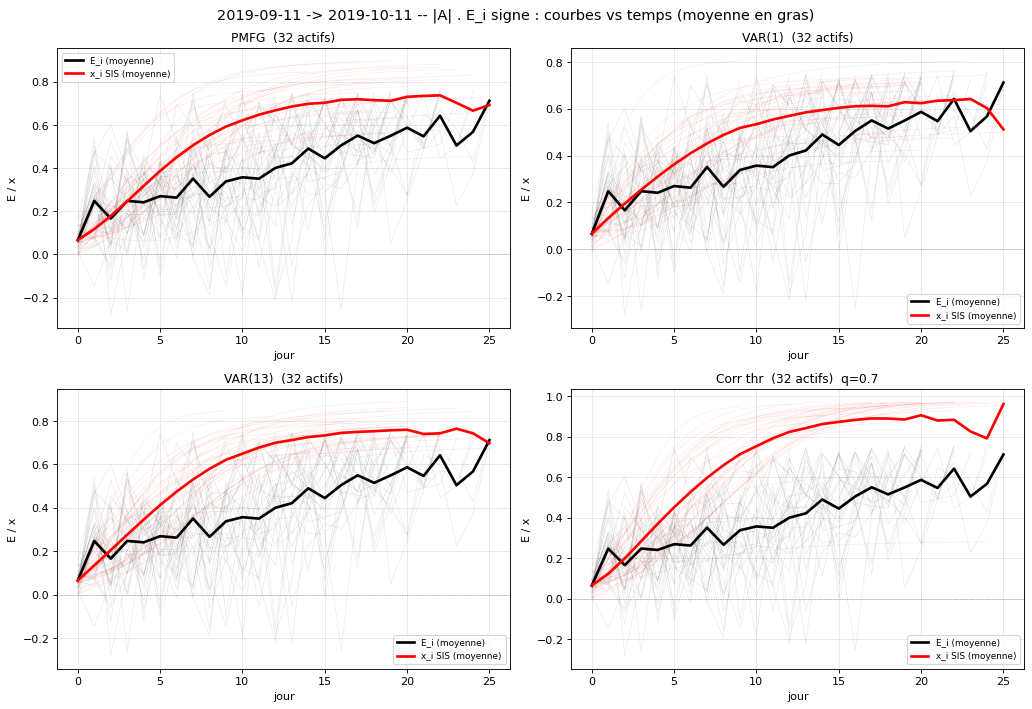

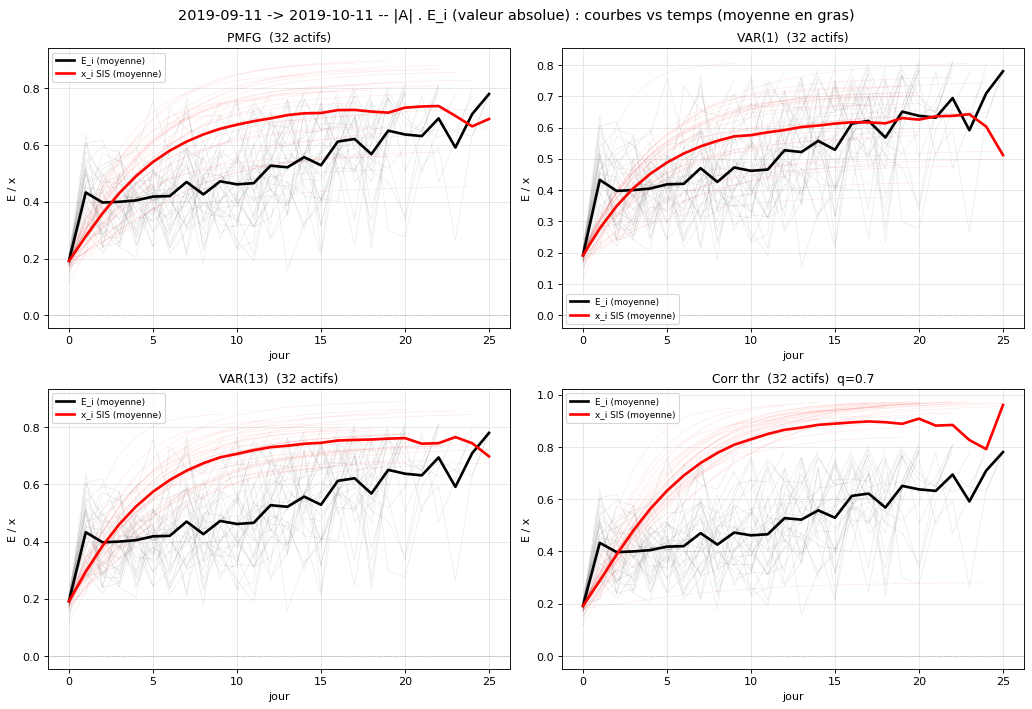

In [83]:
# ── AVEC valeur absolue sur A (|A|) : courbes x_i SIS / E_i vs TEMPS ─────────
# Pendant de la cellule signee, avec |A| (= A_sis). Corr thr au meme seuil 0.7
# pour comparer a iso-parametres. Trajectoires |A| (cache absA_q70 / absAabs_q70).
CORR_THR_HERE = 0.7
A_abs = {
    'PMFG':     A_pmfg,
    'VAR(1)':   A_sis['VAR(1)'],
    'VAR(13)':  A_sis['VAR(13)'],
    'Corr thr': build_filtered_corr(CORR_THR_HERE),
}

def time_grid(cache, traj, lab, tag):
    """Grille 2x2 : E_i(t) noir / x_i(t) SIS rouge, moyenne en gras + spaghetti leger."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
    for ax, m in zip(axes, SIS_MODELS):
        Es, Xs = [], []
        for gi in cache:
            E_i = cache[gi]['E_i']; xt = traj[m][gi]; ok = ~np.isnan(E_i)
            ax.plot(np.arange(len(E_i))[ok], E_i[ok], color='black', alpha=0.08, lw=0.7)
            ax.plot(np.arange(len(xt)), xt, color='red', alpha=0.08, lw=0.7)
            Es.append(E_i); Xs.append(xt)
        mE, mX = _mean_stack(Es), _mean_stack(Xs)
        ax.plot(np.arange(len(mE)), mE, color='black', lw=2.4, label='E_i (moyenne)')
        ax.plot(np.arange(len(mX)), mX, color='red', lw=2.4, label='x_i SIS (moyenne)')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{m}  ({len(cache)} actifs)' + (f'  q={CORR_THR_HERE}' if m == 'Corr thr' else ''), fontsize=11)
        ax.set_xlabel('jour'); ax.set_ylabel('E / x'); ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc='best')
    plt.suptitle(f'{lab} -- |A| . {tag} : courbes vs temps (moyenne en gras)', fontsize=13)
    plt.tight_layout(); plt.show()

for (pa, pb) in _disp(selected):
    lab = f'{all_days[pa]} -> {all_days[pb]}'
    cache_s = period_data[(pa, pb)][0]          # E_i / x0 SIGNES
    cache_a = period_data_abs[(pa, pb)][0]      # E_i / x0 ABSOLUS
    sig_s = make_sig(cache_s, A_abs, B_fit, R_fit, T_long, tol_eq)
    sig_a = make_sig(cache_a, A_abs, B_fit, R_fit, T_long, tol_eq)
    traj_s = disk_cache(f'absA_q70_{all_days[pa]}', sig_s,
        lambda c=cache_s: {m: {gi: integrate(c, gi, A_abs[m]) for gi in c} for m in SIS_MODELS})
    traj_a = disk_cache(f'absAabs_q70_{all_days[pa]}', sig_a,
        lambda c=cache_a: {m: {gi: integrate(c, gi, A_abs[m]) for gi in c} for m in SIS_MODELS})
    time_grid(cache_s, traj_s, lab, 'E_i signe')
    time_grid(cache_a, traj_a, lab, 'E_i (valeur absolue)')


[cache] OK  xstarq_signed_2019-09-11  (rechargé depuis .cache/periods_analysis/xstarq_signed_2019-09-11.5e65a05081169647.pkl)
[cache] OK  xstarq_abs_2019-09-11  (rechargé depuis .cache/periods_analysis/xstarq_abs_2019-09-11.393270b89e0c2d38.pkl)


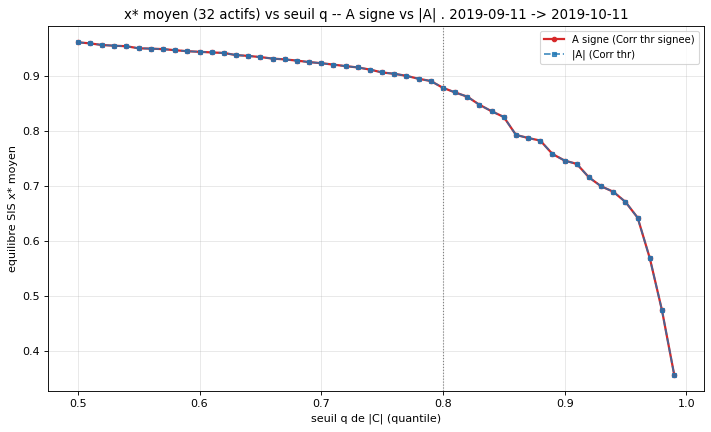

In [84]:
# ── x* moyen (SIS) vs seuil q -- A SANS valeur absolue (Corr thr SIGNEE) ─────
# Matrice 'Corr thr' qui garde le SIGNE des correlations (pas de np.abs). On
# superpose la version |A| (bleu) pour comparer. x* moyenne sur tous les actifs.
Q_SWEEP = np.linspace(0.50, 0.99, 50)
C_signed = np.nan_to_num(np.corrcoef(data.values.T), nan=0.0); np.fill_diagonal(C_signed, 0)

def signed_corr_thr(q):
    thr = np.quantile(C_full[mask_off], q)
    A = np.where(np.abs(C_signed) >= thr, C_signed, 0.0); np.fill_diagonal(A, 0)
    return A

def _xstar(cache, gi, A):
    sol = solve_ivp(ode_sis_bounded, (0, T_long), cache[gi]['x0'],
                    args=(A, B_fit, R_fit), method='LSODA', rtol=1e-6, atol=1e-9)
    return float(sol.y[gi, -1])

for (pa, pb) in _disp(selected):
    cache = period_data[(pa, pb)][0]; lab = f'{all_days[pa]} -> {all_days[pb]}'
    mats_s = {i: signed_corr_thr(q)      for i, q in enumerate(Q_SWEEP)}
    mats_a = {i: build_filtered_corr(q)  for i, q in enumerate(Q_SWEEP)}
    sig_s = make_sig(cache, mats_s, B_fit, R_fit, T_long, 'xstar_signed')
    sig_a = make_sig(cache, mats_a, B_fit, R_fit, T_long, 'xstar_abs')
    res_s = disk_cache(f'xstarq_signed_{all_days[pa]}', sig_s,
        lambda c=cache, mm=mats_s: {i: float(np.mean([_xstar(c, gi, A) for gi in c])) for i, A in mm.items()})
    res_a = disk_cache(f'xstarq_abs_{all_days[pa]}', sig_a,
        lambda c=cache, mm=mats_a: {i: float(np.mean([_xstar(c, gi, A) for gi in c])) for i, A in mm.items()})
    xs_s = np.array([res_s[i] for i in range(len(Q_SWEEP))])
    xs_a = np.array([res_a[i] for i in range(len(Q_SWEEP))])

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(Q_SWEEP, xs_s, 'o-',  color='#d62728', lw=2,   ms=4, label='A signe (Corr thr signee)')
    ax.plot(Q_SWEEP, xs_a, 's--', color='#1f77b4', lw=1.6, ms=3, alpha=0.8, label='|A| (Corr thr)')
    ax.axvline(0.80, color='gray', ls=':', lw=1)
    ax.set_xlabel('seuil q de |C| (quantile)'); ax.set_ylabel('equilibre SIS x* moyen')
    ax.set_title(f'x* moyen ({len(cache)} actifs) vs seuil q -- A signe vs |A| . {lab}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [85]:
# ── Cellule 1 : GROS TABLEAU COMPLET (actifs en crise, fenetre double boucle)
# debut/fin = sous-fenetre par actif issue de strong_rise (la DOUBLE BOUCLE).
# Un R^2 PAR METHODE (matrice) en colonnes.
rows = []
for (pa, pb) in selected:
    cache, fits = period_data[(pa, pb)]
    for gi in cache:
        win = next(((a, b) for a, b in asset_runs(crisis_map[gi]) if b >= pa and a <= pb), None)
        if win is None:
            continue
        res = strong_rise(E_daily_all[gi, win[0]:win[1] + 1])
        if res is None:
            continue
        A0, B0 = win[0] + res[2], win[0] + res[3]
        row = {'actif': asset_names[gi], 'secteur': gi_sector(gi),
               'debut': all_days[A0], 'fin': all_days[B0], 'n_jours': B0 - A0 + 1,
               'periode_large': f'{all_days[pa]}->{all_days[pb]}'}
        for m in SIS_MODELS:
            sl = fits[m][1].get(gi)
            row[f'R2_{m}'] = round(sl['r2'], 3) if sl is not None else np.nan
        rows.append(row)
R2_COLS = [f'R2_{m}' for m in SIS_MODELS]
crise_df = pd.DataFrame(rows)
crise_df = (crise_df.assign(_r2max=crise_df[R2_COLS].max(axis=1))
            .sort_values(['periode_large', '_r2max'], ascending=[True, False])
            .drop(columns='_r2max'))
crise_df.to_csv('results/actifs_crise_R2.csv', index=False)
print(f'{len(crise_df)} lignes (1 par actif x periode) ; R^2 par methode -> results/actifs_crise_R2.csv')
crise_df

537 lignes (1 par actif x periode) ; R^2 par methode -> results/actifs_crise_R2.csv


,actif,secteur,debut,fin,n_jours,periode_large,R2_PMFG,R2_VAR(1),R2_VAR(13),R2_Corr thr
1,AMZN,Consumer Discretionary,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.894,0.912,0.916,0.896
39,CAT,Industrials,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.784,0.813,0.838,0.849
24,TD,Financials,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.783,0.778,0.769,0.836
35,MRK,Healthcare,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.779,0.743,0.759,0.707
21,MC,Financials,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.703,0.724,0.742,0.644
...,...,...,...,...,...,...,...,...,...,...
491,AMGN,Healthcare,2022-08-08,2022-09-21,32,2022-08-03->2022-10-04,0.077,0.078,0.075,0.076
525,ORCL,Information Technology,2022-08-08,2022-09-21,32,2022-08-03->2022-10-04,0.076,0.075,0.073,0.074
478,BKR,Energy,2022-08-19,2022-09-21,23,2022-08-03->2022-10-04,0.060,0.047,0.044,0.049
529,TSM,Information Technology,2022-07-14,2022-09-13,43,2022-08-03->2022-10-04,0.048,0.053,0.042,0.045


In [86]:
# ── Cellule 2 : on affiche le tableau ou R^2 (meilleure methode) > seuil ─────
R2_SEUIL = 0.6
crise_sel = crise_df.assign(_r2max=crise_df[R2_COLS].max(axis=1))
crise_sel = (crise_sel[crise_sel['_r2max'] > R2_SEUIL]
             .sort_values('_r2max', ascending=False)
             .drop(columns='_r2max'))
print(f'{len(crise_sel)} lignes avec R^2 max > {R2_SEUIL}  ({crise_sel.actif.nunique()} actifs distincts)')
crise_sel

34 lignes avec R^2 max > 0.6  (31 actifs distincts)


,actif,secteur,debut,fin,n_jours,periode_large,R2_PMFG,R2_VAR(1),R2_VAR(13),R2_Corr thr
1,AMZN,Consumer Discretionary,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.894,0.912,0.916,0.896
39,CAT,Industrials,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.784,0.813,0.838,0.849
24,TD,Financials,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.783,0.778,0.769,0.836
75,DIS,Consumer Discretionary,2019-07-25,2019-08-16,17,2019-07-16->2019-08-05,0.807,0.800,0.801,0.800
170,XOM,Energy,2020-02-13,2020-03-09,17,2019-12-19->2020-03-09,0.779,0.768,0.779,0.781
35,MRK,Healthcare,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.779,0.743,0.759,0.707
21,MC,Financials,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.703,0.724,0.742,0.644
96,CP,Industrials,2019-07-22,2019-08-14,18,2019-07-16->2019-08-05,0.715,0.690,0.683,0.742
59,MA,Information Technology,2019-04-23,2019-05-13,15,2019-04-01->2019-05-13,0.621,0.634,0.706,0.741
396,COST,Consumer Discretionary,2022-04-04,2022-05-06,24,2022-04-14->2022-05-06,0.728,0.734,0.737,0.674


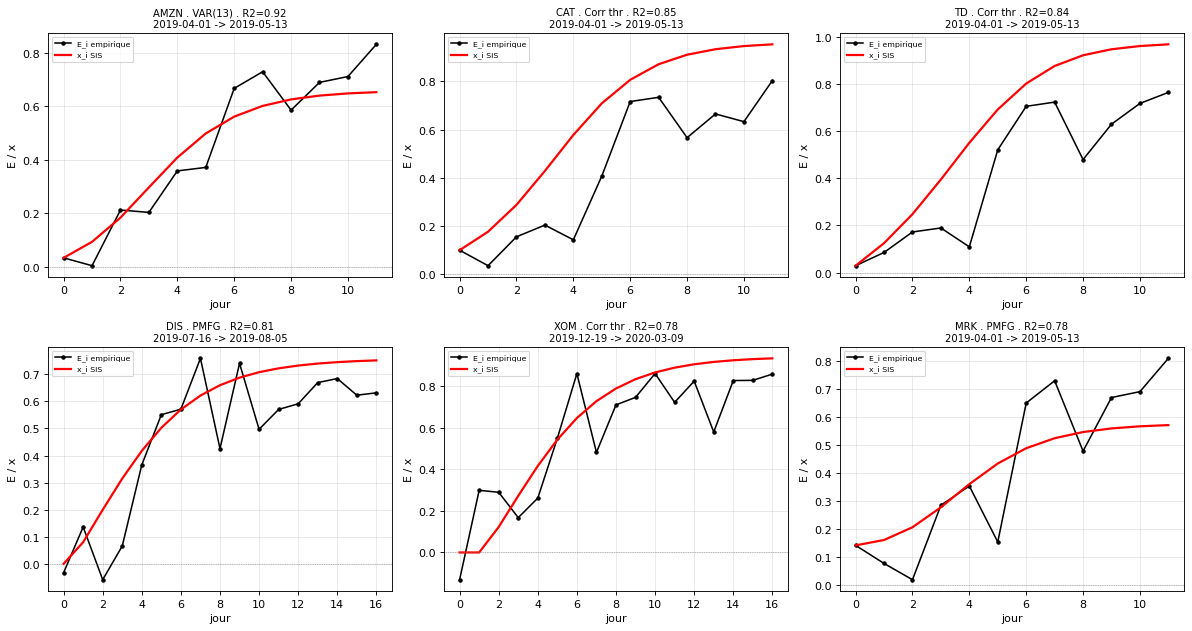

In [87]:
# ── Quelques courbes parmi R^2 > seuil : E_i empirique vs x_i SIS (vs temps) ─
# Top 6 par R^2 (change 'pick' pour en voir d'autres / un echantillon aleatoire).
cands = []
for (pa, pb) in selected:
    cache, fits = period_data[(pa, pb)]
    for m in SIS_MODELS:
        for gi, sl in fits[m][1].items():
            if sl['r2'] > R2_SEUIL:
                cands.append((sl['r2'], pa, pb, gi, m))
cands.sort(key=lambda c: -c[0])
seen, pick = set(), []                 # 6 actifs DISTINCTS (meilleure matrice de chacun)
for cand in cands:
    if cand[3] not in seen:
        seen.add(cand[3]); pick.append(cand)
    if len(pick) == 6:
        break

fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
for ax, (r2, pa, pb, gi, m) in zip(axes, pick):
    E_i, x_traj = period_data[(pa, pb)][1][m][0][gi]
    ok = ~np.isnan(E_i); t = np.arange(len(E_i))
    ax.plot(t[ok], E_i[ok], 'o-', color='black', ms=3, lw=1.4, label='E_i empirique')
    ax.plot(t, x_traj, '-', color='red', lw=2.0, label='x_i SIS')
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_title(f'{asset_names[gi]} . {m} . R2={r2:.2f}\n{all_days[pa]} -> {all_days[pb]}', fontsize=9)
    ax.set_xlabel('jour'); ax.set_ylabel('E / x'); ax.grid(alpha=0.3); ax.legend(fontsize=7)
for ax in axes[len(pick):]:
    ax.axis('off')
plt.tight_layout(); plt.show()


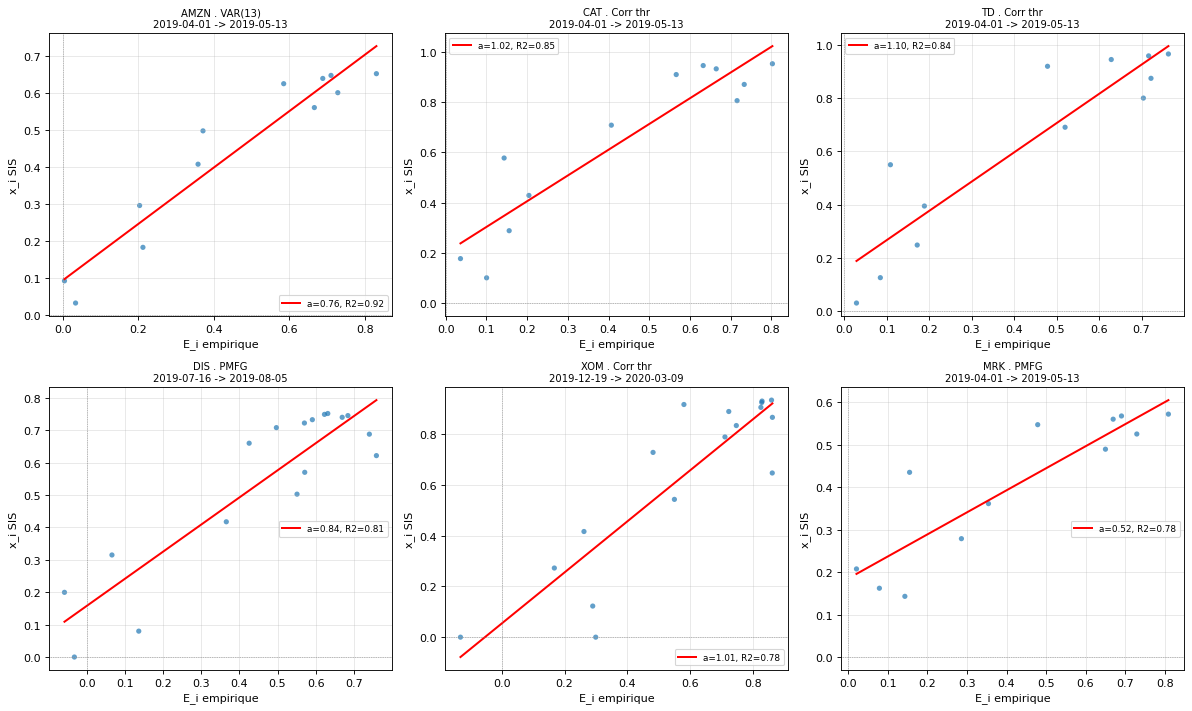

In [88]:
# ── Scatter x_i SIS vs E_i pour les memes courbes (pick, R^2 > seuil) ───────
# Le nuage + la droite de regression : c'est ce qui donne le R^2 du tableau.
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()
for ax, (r2, pa, pb, gi, m) in zip(axes, pick):
    E_i, x_traj = period_data[(pa, pb)][1][m][0][gi]
    ok = ~np.isnan(E_i); E, X = E_i[ok], x_traj[ok]
    ax.scatter(E, X, s=22, color='#1f77b4', alpha=0.7, edgecolors='none')
    f = linregress(E, X); xs = np.linspace(E.min(), E.max(), 50)
    ax.plot(xs, f.slope * xs + f.intercept, color='red', lw=1.8,
            label=f'a={f.slope:.2f}, R2={f.rvalue**2:.2f}')
    ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
    ax.set_title(f'{asset_names[gi]} . {m}\n{all_days[pa]} -> {all_days[pb]}', fontsize=9)
    ax.set_xlabel('E_i empirique'); ax.set_ylabel('x_i SIS'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
for ax in axes[len(pick):]:
    ax.axis('off')
plt.tight_layout(); plt.show()


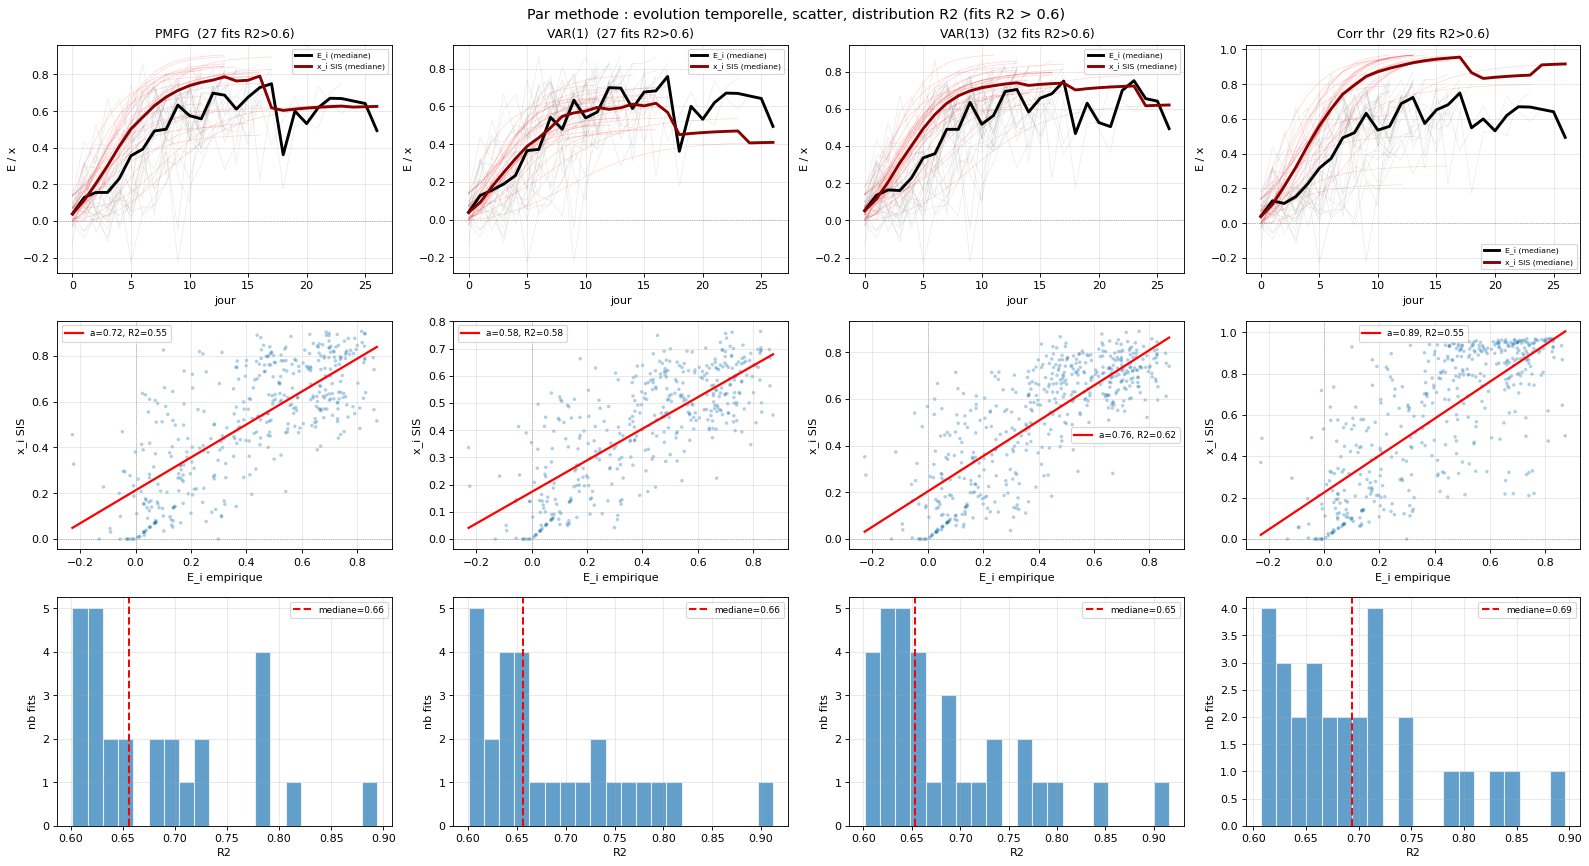

In [89]:
# ── 4 methodes x 3 vues : evolution temporelle | scatter | distribution R^2 ──
# Pour chaque methode (colonne) on garde TOUS les fits R^2 > R2_SEUIL (toutes
# periodes). Haut : E_i (gris) / x_i (rouge) en fonction du jour + medianes en
# fonce. Milieu : scatter x_i SIS vs E_i + regression. Bas : distribution des R^2.
def _med(series):                     # mediane par jour relatif (padding NaN)
    if not series:
        return np.array([])
    L = max(len(v) for v in series)
    M = np.full((len(series), L), np.nan)
    for r, v in enumerate(series):
        M[r, :len(v)] = v
    return np.nanmedian(M, axis=0)

fig, axes = plt.subplots(3, len(SIS_MODELS), figsize=(5 * len(SIS_MODELS), 11))
for j, m in enumerate(SIS_MODELS):
    Es, Xs, E_all, X_all, r2s = [], [], [], [], []
    for (pa, pb) in selected:
        fits = period_data[(pa, pb)][1]
        for gi, sl in fits[m][1].items():
            if sl['r2'] > R2_SEUIL:
                E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
                Es.append(E_i); Xs.append(x_traj)
                E_all.append(E_i[ok]); X_all.append(x_traj[ok]); r2s.append(sl['r2'])

    # haut : evolution temporelle E_i (gris) / x_i (rouge) + medianes en fonce
    axt = axes[0, j]
    for E_i, x_traj in zip(Es, Xs):
        ok = ~np.isnan(E_i)
        axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
        axt.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
    med_E, med_X = _med(Es), _med(Xs)
    if len(med_E):
        axt.plot(np.arange(len(med_E)), med_E, color='black', lw=2.6, label='E_i (mediane)')
        axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
    axt.axhline(0, color='gray', lw=0.6, ls=':')
    axt.set_title(f'{m}  ({len(Es)} fits R2>{R2_SEUIL})', fontsize=11)
    axt.set_xlabel('jour'); axt.set_ylabel('E / x'); axt.grid(alpha=0.3)
    if Es:
        axt.legend(fontsize=7)

    # milieu : scatter x_i SIS vs E_i + regression agregee
    axs = axes[1, j]
    if E_all:
        Ec, Xc = np.concatenate(E_all), np.concatenate(X_all)
        axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
        axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                 label=f'a={f.slope:.2f}, R2={f.rvalue**2:.2f}')
        axs.legend(fontsize=8)
    axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
    axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS'); axs.grid(alpha=0.3)

    # bas : distribution des R^2 (mediane en pointilles rouges)
    axd = axes[2, j]
    if r2s:
        axd.hist(r2s, bins=20, color='#1f77b4', alpha=0.7, edgecolor='white')
        med_r2 = np.median(r2s)
        axd.axvline(med_r2, color='red', ls='--', lw=1.8, label=f'mediane={med_r2:.2f}')
        axd.legend(fontsize=8)
    axd.set_xlabel('R2'); axd.set_ylabel('nb fits'); axd.grid(alpha=0.3)

plt.suptitle(f'Par methode : evolution temporelle, scatter, distribution R2 (fits R2 > {R2_SEUIL})', fontsize=13)
plt.tight_layout(); plt.show()

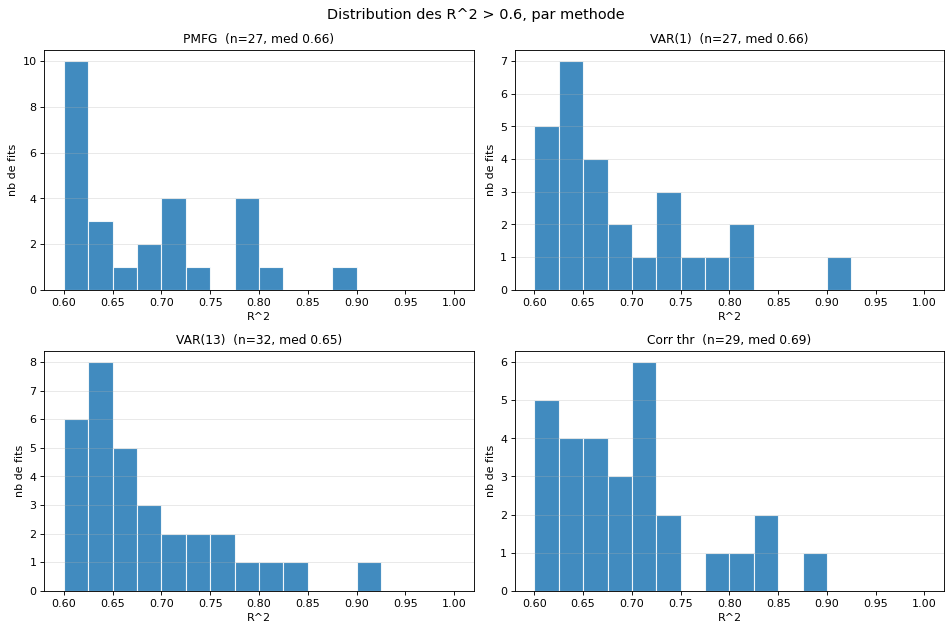

In [90]:
# ── Histogrammes des R^2 > seuil, un par methode (2x2) ──────────────────────
bins = np.linspace(R2_SEUIL, 1.0, 17)
fig, axes = plt.subplots(2, 2, figsize=(12, 8)); axes = axes.flatten()
for ax, m in zip(axes, SIS_MODELS):
    r = np.array([sl['r2'] for (pa, pb) in selected
                  for sl in period_data[(pa, pb)][1][m][1].values() if sl['r2'] > R2_SEUIL])
    ax.hist(r, bins=bins, color='#1f77b4', alpha=0.85, edgecolor='white')
    ax.set_title(f'{m}  (n={len(r)}, med {np.median(r):.2f})' if len(r) else f'{m} (vide)', fontsize=11)
    ax.set_xlabel('R^2'); ax.set_ylabel('nb de fits'); ax.grid(alpha=0.3, axis='y')
plt.suptitle(f'Distribution des R^2 > {R2_SEUIL}, par methode', fontsize=13)
plt.tight_layout(); plt.show()


In [91]:
# ── % d'actifs avec R^2 > seuil, pour VAR(1) et VAR(13) (global + par periode)
for m in ['VAR(1)', 'VAR(13)']:
    tot = above = 0
    print(f'=== {m} ===  (% actifs R2 > {R2_SEUIL})')
    for (pa, pb) in selected:
        sl = period_data[(pa, pb)][1][m][1]
        n = len(sl); a = sum(1 for x in sl.values() if x['r2'] > R2_SEUIL)
        tot += n; above += a
        print(f'  {all_days[pa]} -> {all_days[pb]} : {a:2d}/{n:2d} = {100*a/n:4.0f}%')
    print(f'  GLOBAL : {above}/{tot} = {100*above/tot:.1f}%\n')


=== VAR(1) ===  (% actifs R2 > 0.6)
  2019-04-01 -> 2019-05-13 : 13/72 =   18%
  2019-07-16 -> 2019-08-05 :  5/38 =   13%
  2019-09-11 -> 2019-10-11 :  1/32 =    3%
  2019-12-19 -> 2020-03-09 :  2/88 =    2%
  2021-08-10 -> 2021-10-07 :  0/39 =    0%
  2021-11-02 -> 2021-12-01 :  0/33 =    0%
  2021-12-28 -> 2022-01-25 :  2/92 =    2%
  2022-04-14 -> 2022-05-06 :  4/65 =    6%
  2022-08-03 -> 2022-10-04 :  0/78 =    0%
  GLOBAL : 27/537 = 5.0%

=== VAR(13) ===  (% actifs R2 > 0.6)
  2019-04-01 -> 2019-05-13 : 16/72 =   22%
  2019-07-16 -> 2019-08-05 :  5/38 =   13%
  2019-09-11 -> 2019-10-11 :  2/32 =    6%
  2019-12-19 -> 2020-03-09 :  2/88 =    2%
  2021-08-10 -> 2021-10-07 :  0/39 =    0%
  2021-11-02 -> 2021-12-01 :  0/33 =    0%
  2021-12-28 -> 2022-01-25 :  2/92 =    2%
  2022-04-14 -> 2022-05-06 :  5/65 =    8%
  2022-08-03 -> 2022-10-04 :  0/78 =    0%
  GLOBAL : 32/537 = 6.0%



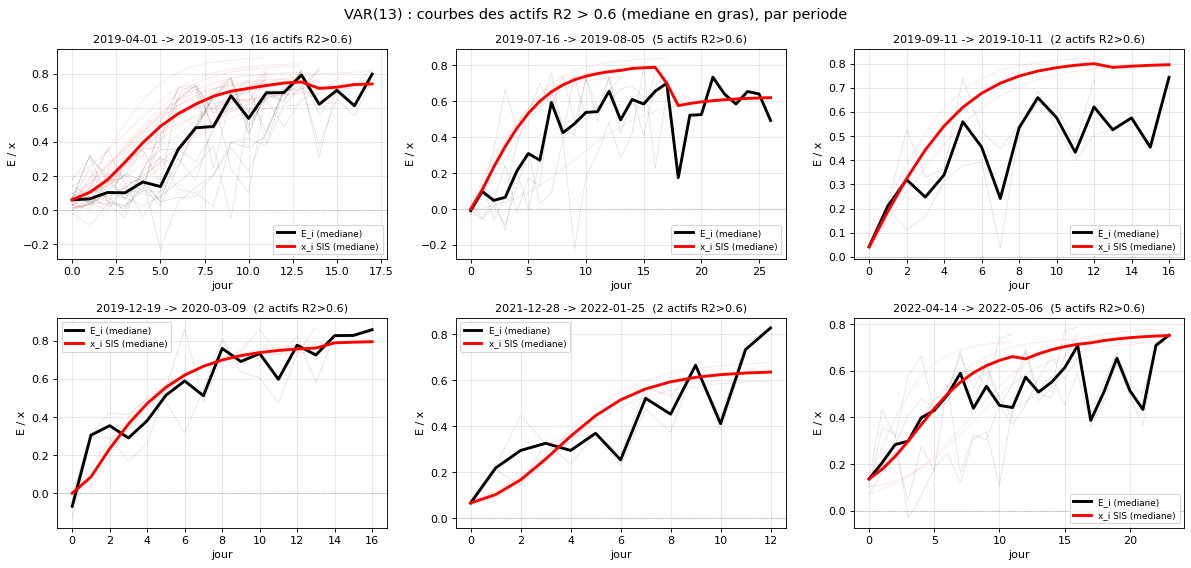

In [92]:
# ── VAR(13) : par periode, courbes des actifs R^2>seuil + MEDIANE en gras ───
m = 'VAR(13)'
def _med(series):                     # mediane par jour relatif (padding NaN), autonome
    if not series:
        return np.array([])
    L = max(len(v) for v in series)
    M = np.full((len(series), L), np.nan)
    for r, v in enumerate(series):
        M[r, :len(v)] = v
    return np.nanmedian(M, axis=0)

periods_ok = [(pa, pb) for (pa, pb) in selected
              if any(sl['r2'] > R2_SEUIL for sl in period_data[(pa, pb)][1][m][1].values())]
ncol = 3; nrow = int(np.ceil(len(periods_ok) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.6 * nrow)); axes = np.atleast_1d(axes).flatten()
for ax, (pa, pb) in zip(axes, periods_ok):
    fits = period_data[(pa, pb)][1]
    kept = [gi for gi, sl in fits[m][1].items() if sl['r2'] > R2_SEUIL]
    Es, Xs = [], []
    for gi in kept:
        E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
        ax.plot(np.arange(len(E_i))[ok], E_i[ok], color='black', alpha=0.12, lw=0.7)
        ax.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.12, lw=0.7)
        Es.append(E_i); Xs.append(x_traj)
    med_E, med_X = _med(Es), _med(Xs)     # mediane bien visible par-dessus
    if len(med_E):
        ax.plot(np.arange(len(med_E)), med_E, color='black', lw=2.6, label='E_i (mediane)')
        ax.plot(np.arange(len(med_X)), med_X, color='red', lw=2.6, label='x_i SIS (mediane)')
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_title(f'{all_days[pa]} -> {all_days[pb]}  ({len(kept)} actifs R2>{R2_SEUIL})', fontsize=10)
    ax.set_xlabel('jour'); ax.set_ylabel('E / x'); ax.grid(alpha=0.3)
    if kept:
        ax.legend(fontsize=8)
for ax in axes[len(periods_ok):]:
    ax.axis('off')
plt.suptitle(f'{m} : courbes des actifs R2 > {R2_SEUIL} (mediane en gras), par periode', fontsize=13)
plt.tight_layout(); plt.show()

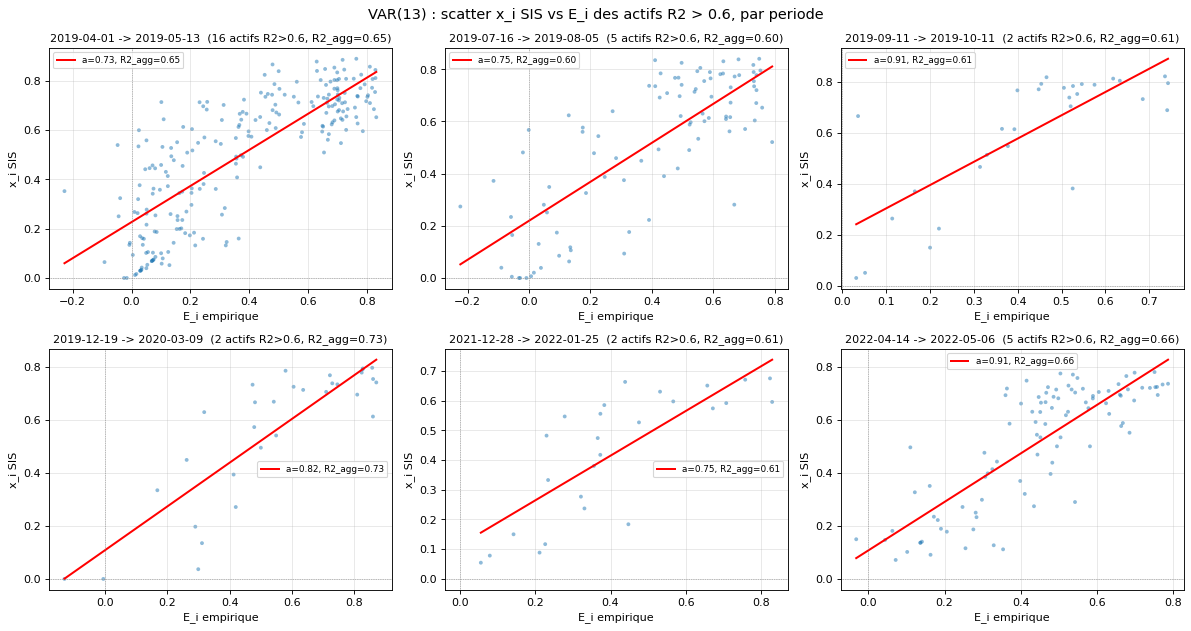

In [93]:
# ── VAR(13) : par periode, scatter x_i SIS vs E_i des actifs R^2>seuil ──────
m = 'VAR(13)'
periods_ok = [(pa, pb) for (pa, pb) in selected
              if any(sl['r2'] > R2_SEUIL for sl in period_data[(pa, pb)][1][m][1].values())]
ncol = 3; nrow = int(np.ceil(len(periods_ok) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4 * nrow)); axes = np.atleast_1d(axes).flatten()
for ax, (pa, pb) in zip(axes, periods_ok):
    fits = period_data[(pa, pb)][1]
    kept = [gi for gi, sl in fits[m][1].items() if sl['r2'] > R2_SEUIL]
    E_all, X_all = [], []
    for gi in kept:
        E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
        E_all.append(E_i[ok]); X_all.append(x_traj[ok])
    E_all, X_all = np.concatenate(E_all), np.concatenate(X_all)
    ax.scatter(E_all, X_all, s=12, color='#1f77b4', alpha=0.5, edgecolors='none')
    f = linregress(E_all, X_all); xs = np.linspace(E_all.min(), E_all.max(), 50)
    ax.plot(xs, f.slope * xs + f.intercept, color='red', lw=1.8,
            label=f'a={f.slope:.2f}, R2_agg={f.rvalue**2:.2f}')
    ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
    ax.set_title(f'{all_days[pa]} -> {all_days[pb]}  ({len(kept)} actifs R2>{R2_SEUIL}, R2_agg={f.rvalue**2:.2f})', fontsize=10)
    ax.set_xlabel('E_i empirique'); ax.set_ylabel('x_i SIS'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
for ax in axes[len(periods_ok):]:
    ax.axis('off')
plt.suptitle(f'{m} : scatter x_i SIS vs E_i des actifs R2 > {R2_SEUIL}, par periode', fontsize=13)
plt.tight_layout(); plt.show()


chaque méthode: plot avec evolution par jour de x_i coure grise, 
4 plot evolution et scatters plots
distribution R2 median pointillé rouge, latex pour R2, enlever titre. 3eme ligne
meme stock meme periode ? 
methode differente pour distribution crise par periode ?
R^2 0.8?

choix periode crise,partie négative correlation, threshold crise 0.7 moyenne ? pente descendante . 0.6 sur 12 jours ? si pas 12 jours au dessus du threshold.

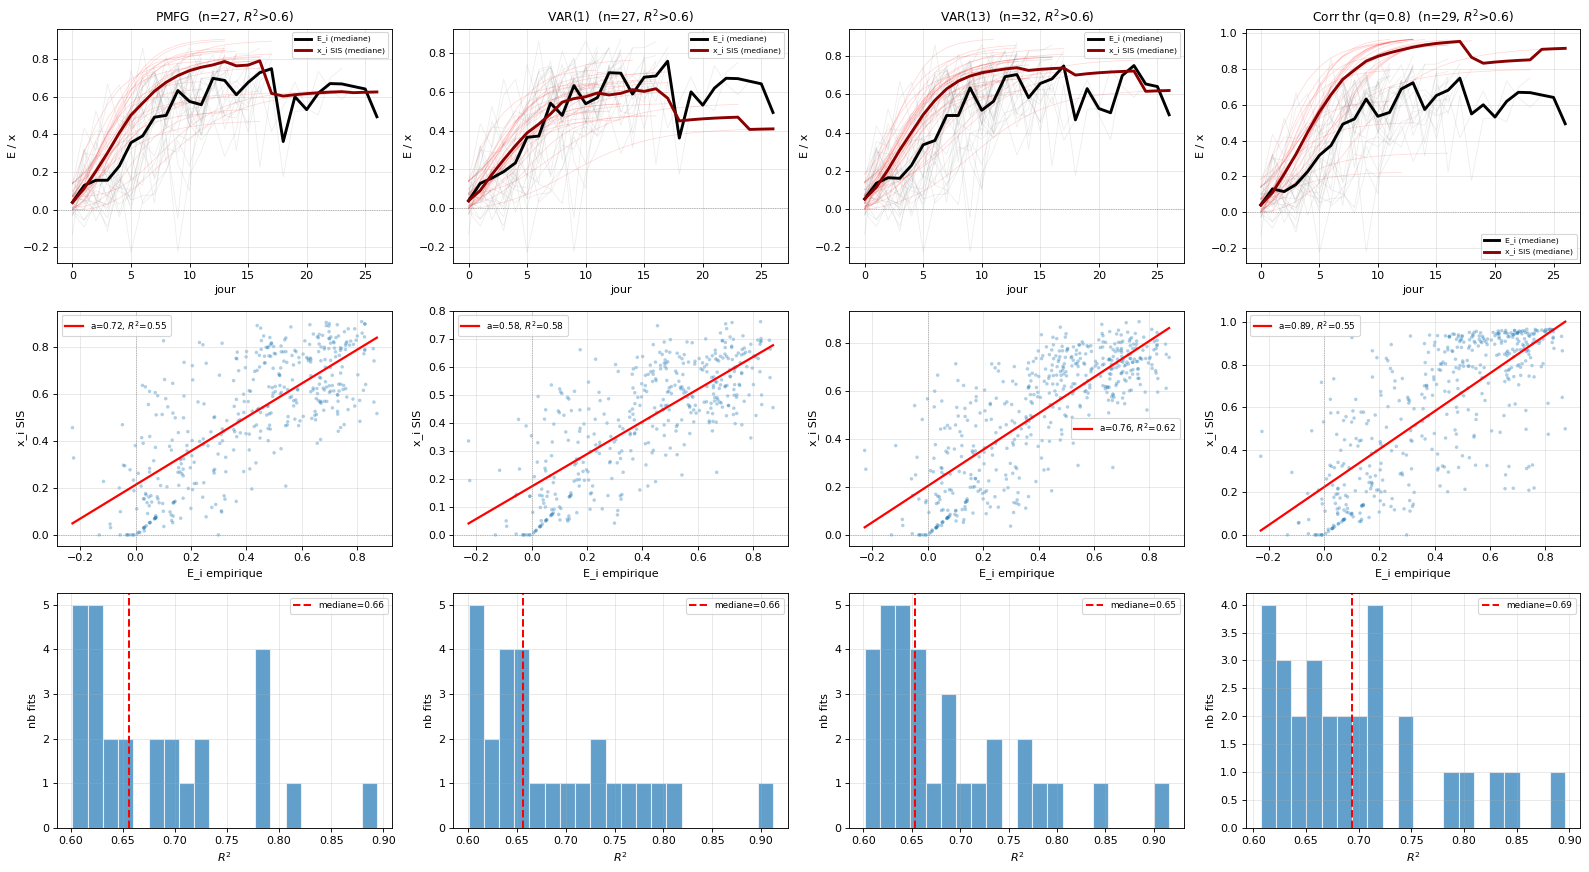

In [94]:
# ── 4 methodes x 3 vues : evolution temporelle | scatter | distribution R^2 ──
# Pour chaque methode (colonne) on garde TOUS les fits R^2 > R2_SEUIL (toutes
# periodes). Haut : E_i (gris) / x_i (rouge) en fonction du jour + medianes en
# fonce. Milieu : scatter x_i SIS vs E_i + regression. Bas : distribution des R^2.
def _med(series):                     # mediane par jour relatif (padding NaN)
    if not series:
        return np.array([])
    L = max(len(v) for v in series)
    M = np.full((len(series), L), np.nan)
    for r, v in enumerate(series):
        M[r, :len(v)] = v
    return np.nanmedian(M, axis=0)

fig, axes = plt.subplots(3, len(SIS_MODELS), figsize=(5 * len(SIS_MODELS), 11))
for j, m in enumerate(SIS_MODELS):
    Es, Xs, E_all, X_all, r2s = [], [], [], [], []
    for (pa, pb) in selected:
        fits = period_data[(pa, pb)][1]
        for gi, sl in fits[m][1].items():
            if sl['r2'] > R2_SEUIL:
                E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
                Es.append(E_i); Xs.append(x_traj)
                E_all.append(E_i[ok]); X_all.append(x_traj[ok]); r2s.append(sl['r2'])

    # haut : evolution temporelle E_i (gris) / x_i (rouge) + medianes en fonce
    axt = axes[0, j]
    for E_i, x_traj in zip(Es, Xs):
        ok = ~np.isnan(E_i)
        axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
        axt.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
    med_E, med_X = _med(Es), _med(Xs)
    if len(med_E):
        axt.plot(np.arange(len(med_E)), med_E, color='black', lw=2.6, label='E_i (mediane)')
        axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
    axt.axhline(0, color='gray', lw=0.6, ls=':')
    m_lbl = f'{m} (q={CORR_THRESHOLD})' if m == 'Corr thr' else m
    axt.set_title(rf'{m_lbl}  (n={len(Es)}, $R^2$>{R2_SEUIL})', fontsize=11)
    axt.set_xlabel('jour'); axt.set_ylabel('E / x'); axt.grid(alpha=0.3)
    if Es:
        axt.legend(fontsize=7)

    # milieu : scatter x_i SIS vs E_i + regression agregee
    axs = axes[1, j]
    if E_all:
        Ec, Xc = np.concatenate(E_all), np.concatenate(X_all)
        axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
        axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                 label=rf'a={f.slope:.2f}, $R^2$={f.rvalue**2:.2f}')
        axs.legend(fontsize=8)
    axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
    axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS'); axs.grid(alpha=0.3)

    # bas : distribution des R^2 (mediane en pointilles rouges)
    axd = axes[2, j]
    if r2s:
        axd.hist(r2s, bins=20, color='#1f77b4', alpha=0.7, edgecolor='white')
        med_r2 = np.median(r2s)
        axd.axvline(med_r2, color='red', ls='--', lw=1.8, label=f'mediane={med_r2:.2f}')
        axd.legend(fontsize=8)
    axd.set_xlabel(r'$R^2$'); axd.set_ylabel('nb fits'); axd.grid(alpha=0.3)

plt.tight_layout(); plt.show()